# EDA cổ phiếu theo lịch phiên — bản thử nghiệm độc lập

Notebook này **không thay thế** `Stock_EDA.ipynb`. Mục tiêu là tạo một pipeline EDA đủ dễ đọc để trả lời hai câu hỏi thực tế trước khi sang ML:

1. Công ty nào có dữ liệu đủ ổn định để giữ lại làm candidate?
2. Horizon `T` nào là **ứng viên EDA chính** để mang sang notebook ML kiểm định?

Pipeline:

> Raw CSV → calendar/session panel → xử lý `Volume=0` và gap → feature/target đúng phiên → cổng chất lượng công ty → shortlist T → biểu đồ kết luận

Nguyên tắc chống leakage:

- Toàn bộ dữ liệu đến `ANALYSIS_END` vẫn được audit.
- Chất lượng công ty và shortlist T chỉ dùng dữ liệu đến `EDA_DECISION_END`.
- Phần sau `EDA_DECISION_END` được giữ lại cho kiểm định tương lai, không tham gia quyết định EDA.

Giới hạn quan trọng:

- `PrimaryT` là ứng viên ưu tiên cho ML, **không phải T tối ưu cuối cùng**. Notebook ML vẫn phải walk-forward/out-of-sample.
- Danh sách 30 mã VN và 20 mã US hiện tại chỉ là candidate pool và có thể thay đổi.
- Lịch HOSE trong bản test là registry cục bộ 2020–2026. Trước ML chính thức phải đối chiếu với thông báo HOSE/VNX và đóng băng calendar version cuối cùng.

In [1]:
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import exchange_calendars as xcals
from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning)
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

ROOT = Path.cwd()
if not (ROOT / "Raw Data").exists():
    ROOT = ROOT.parent

CONFIG = {
    "ANALYSIS_START": "2020-01-01",
    "ANALYSIS_END": "2026-09-01",
    "HORIZONS": [1, 5, 10, 20, 30, 60],
    "EDA_DECISION_END": "2024-12-31",
    "MIN_TARGET_COVERAGE_FOR_T": 0.90,
    "MIN_STRICT_PATH_COVERAGE_FOR_T": 0.65,
    "MAX_PUP_YEAR_STD_FOR_T": 0.10,
    "MIN_PUP_FOR_UP_SHORTLIST": 0.50,
    "MAX_COMPANY_PUP_YEAR_STD_AT_COMMON_T": 0.12,
    "MIN_TARGET_CLASS_SHARE": 0.30,
    "SHOW_DETAILED_SELECTED_HEATMAPS": True,
    "MARKET_WIDE_GAP_THRESHOLD": 0.50,
    "SESSION_HEALTHY_THRESHOLD": 0.90,
    "BREADTH_SENSITIVITY": [0.40, 0.50, 0.60],
    "MIN_HISTORY_YEARS": 3.0,
    "MIN_TOTAL_COVERAGE": 0.98,
    "MIN_YEARLY_COVERAGE": 0.95,
    "MAX_UNRESOLVED_GAP": 3,
    "MIN_VALID_TARGETS": 500,
    "SELECTED_MARKET": "VN",
    "SELECTED_TICKER": "FPT",
    "EXPORT_XLSX": True,
}

RAW_DIR = ROOT / "Raw Data"
OUT_DIR = ROOT / "outputs" / "test"
OUT_DIR.mkdir(parents=True, exist_ok=True)

assert pd.Timestamp(CONFIG["ANALYSIS_START"]) <= pd.Timestamp(CONFIG["EDA_DECISION_END"]) < pd.Timestamp(CONFIG["ANALYSIS_END"])
assert 0 < CONFIG["MARKET_WIDE_GAP_THRESHOLD"] <= CONFIG["SESSION_HEALTHY_THRESHOLD"] <= 1
assert CONFIG["HORIZONS"] == sorted(set(CONFIG["HORIZONS"]))

print(f"Project root: {ROOT}")
print(f"Analysis: {CONFIG['ANALYSIS_START']} → {CONFIG['ANALYSIS_END']}")
print(f"EDA decision window: {CONFIG['ANALYSIS_START']} → {CONFIG['EDA_DECISION_END']}")
print(f"Candidate T: {CONFIG['HORIZONS']}")


Project root: C:\Users\DELL\projects\P4AIDS - Stock
Analysis: 2020-01-01 → 2026-09-01
EDA decision window: 2020-01-01 → 2024-12-31
Candidate T: [1, 5, 10, 20, 30, 60]


## 0. Cách sử dụng notebook khi dữ liệu hoặc yêu cầu thay đổi

Notebook tự quét toàn bộ CSV bên dưới `Raw Data`; không có danh sách ticker viết cứng. Quy trình sử dụng lại:

| Khi muốn thay đổi | Chỉnh ở đâu | Điều gì sẽ tự tính lại |
|---|---|---|
| Thêm/bớt công ty | Thêm/bớt CSV trong `Raw Data` | Candidate pool, coverage, danh sách công ty cuối |
| Thử T khác | `CONFIG["HORIZONS"]` | Target, shortlist T, Common T và danh sách công ty |
| Đổi giai đoạn EDA | `EDA_DECISION_END` | Mọi tiêu chí chọn công ty/T; dữ liệu sau mốc không bị nhìn trước |
| Siết/nới chất lượng raw | `MIN_TOTAL_COVERAGE`, `MIN_YEARLY_COVERAGE`, `MAX_UNRESOLVED_GAP` | Cổng `AcceptedForML` |
| Siết/nới lựa chọn T | Các biến kết thúc bằng `_FOR_T` | Shortlist và Common T theo thị trường |
| Siết/nới công ty tại Common T | `MAX_COMPANY_PUP_YEAR_STD_AT_COMMON_T`, `MIN_TARGET_CLASS_SHARE` | Danh sách công ty cuối |
| Đổi ticker minh họa | `SELECTED_MARKET`, `SELECTED_TICKER` | Chỉ các chart minh họa; không làm đổi quyết định |
| Bật/tắt heatmap chi tiết từng công ty | `SHOW_DETAILED_SELECTED_HEATMAPS` | Chỉ thay output chart, không đổi kết quả chọn |

Luồng quyết định cuối:

> Tất cả CSV → data-quality gate → chọn một Common T cho mỗi thị trường → kiểm tra từng công ty tại Common T → danh sách cuối cho ML

Các ngưỡng là policy EDA có thể điều chỉnh, không phải hằng số tài chính phổ quát. Mỗi lần sửa CONFIG cần chạy lại từ đầu và đọc cell **KẾT LUẬN CUỐI CÙNG**.

## 1. Lịch phiên theo thị trường

US dùng lịch `XNYS` từ `exchange_calendars`. Với dữ liệu ngày trong phạm vi hiện tại, calendar này là session index chung cho nhóm US.

VN dùng registry ngày nghỉ cục bộ cho giai đoạn 2020–2026. Registry giúp notebook test chạy độc lập và tốt hơn `pd.bdate_range` thuần túy, nhưng vẫn được gắn nhãn `LOCAL_REVIEWED_CANDIDATE`: trước khi dùng cho ML cuối cùng cần đối chiếu từng năm với thông báo HOSE/VNX.

Điểm cần nhớ khi đọc kết quả:

- Ngày không nằm trong calendar không phải session và không được tính vào `T`.
- Một ngày nằm trong calendar nhưng vendor mất dữ liệu vẫn là session; ngày đó được giữ trên panel với `NaN`.
- Market breadth không được dùng để tự ý đổi một session thành ngày nghỉ.


In [2]:
# Các ngày đóng cửa ứng viên trong khoảng nghiên cứu. Weekend có xuất hiện trong
# nguồn tham chiếu cũng không ảnh hưởng vì base calendar chỉ gồm Mon-Fri.
HOSE_HOLIDAYS = pd.DatetimeIndex(pd.to_datetime([
    # 2020
    "2020-01-01", "2020-01-23", "2020-01-24", "2020-01-27", "2020-01-28", "2020-01-29",
    "2020-04-02", "2020-04-30", "2020-05-01", "2020-09-02",
    # 2021
    "2021-01-01", "2021-02-10", "2021-02-11", "2021-02-12", "2021-02-15", "2021-02-16",
    "2021-04-21", "2021-04-30", "2021-05-03", "2021-09-02", "2021-09-03",
    # 2022
    "2022-01-03", "2022-01-31", "2022-02-01", "2022-02-02", "2022-02-03", "2022-02-04",
    "2022-04-11", "2022-05-02", "2022-05-03", "2022-09-01", "2022-09-02",
    # 2023
    "2023-01-02", "2023-01-20", "2023-01-23", "2023-01-24", "2023-01-25", "2023-01-26",
    "2023-05-01", "2023-05-02", "2023-05-03", "2023-09-01", "2023-09-04",
    # 2024
    "2024-01-01", "2024-02-08", "2024-02-09", "2024-02-12", "2024-02-13", "2024-02-14",
    "2024-04-18", "2024-04-29", "2024-04-30", "2024-05-01", "2024-09-02", "2024-09-03",
    # 2025
    "2025-01-01", "2025-01-27", "2025-01-28", "2025-01-29", "2025-01-30", "2025-01-31",
    "2025-04-07", "2025-04-30", "2025-05-01", "2025-09-01", "2025-09-02",
    # 2026 đến ANALYSIS_END
    "2026-01-01", "2026-01-02", "2026-02-16", "2026-02-17", "2026-02-18", "2026-02-19",
    "2026-02-20", "2026-04-27", "2026-04-30", "2026-05-01",
])).normalize()

def canonical_sessions(market, start, end):
    start, end = pd.Timestamp(start), pd.Timestamp(end)
    if market == "US":
        cal = xcals.get_calendar("XNYS")
        sessions = cal.sessions_in_range(start, end)
        return pd.DatetimeIndex(sessions).tz_localize(None).normalize(), "XNYS/exchange_calendars"
    weekdays = pd.bdate_range(start, end).normalize()
    sessions = weekdays.difference(HOSE_HOLIDAYS)
    return sessions, "HOSE local registry candidate — official annual verification required"

CALENDARS = {}
CALENDAR_ROWS = []
for market in ["VN", "US"]:
    sessions, source = canonical_sessions(market, CONFIG["ANALYSIS_START"], CONFIG["ANALYSIS_END"])
    CALENDARS[market] = sessions
    CALENDAR_ROWS.append({
        "Market": market,
        "Start": sessions.min(),
        "End": sessions.max(),
        "SessionCount": len(sessions),
        "Source": source,
        "VerificationStatus": "CANDIDATE_REVIEW_REQUIRED" if market == "VN" else "LIBRARY_CALENDAR",
    })

CALENDAR_AUDIT = pd.DataFrame(CALENDAR_ROWS)
display(CALENDAR_AUDIT)


,Market,Start,End,SessionCount,Source,VerificationStatus
0,VN,2020-01-02,2026-09-01,1664,HOSE local registry candidate — official annua...,CANDIDATE_REVIEW_REQUIRED
1,US,2020-01-02,2026-09-01,1675,XNYS/exchange_calendars,LIBRARY_CALENDAR


## 2. Đọc raw data vào staging

Cell này tự quét mọi CSV trong `Raw Data`, nên nếu thêm công ty mới thì notebook không cần sửa danh sách ticker bằng tay.

Staging chỉ chuẩn hóa schema và gắn cờ lỗi. `Volume=0` vẫn được giữ nguyên; chưa có row nào bị loại vì volume. Duplicate date được audit rồi giữ bản ghi cuối để mỗi ticker chỉ có một observation raw trên một ngày.

Kết quả chính:

- `STAGING`: dữ liệu chuẩn hóa và toàn bộ cờ chất lượng raw.
- `FILE_AUDIT`: số dòng, duplicate, zero volume và lỗi OHLC theo file.


In [3]:
COLUMN_ALIASES = {
    "Date": ["date", "datetime", "timestamp", "time"],
    "Open": ["open", "openprice", "priceopen"],
    "High": ["high", "highprice", "pricehigh"],
    "Low": ["low", "lowprice", "pricelow"],
    "Close": ["close", "closeprice", "priceclose"],
    "Adj Close": ["adjclose", "adjustedclose", "adj_close", "adj close"],
    "Volume": ["volume", "vol"],
    "Dividends": ["dividends", "dividend"],
    "Stock Splits": ["stocksplits", "stock splits", "splits", "split"],
}
REQUIRED = ["Date", "Open", "High", "Low", "Close", "Adj Close", "Volume"]
NUMERIC = ["Open", "High", "Low", "Close", "Adj Close", "Volume", "Dividends", "Stock Splits"]

def _norm_col(x):
    return re.sub(r"[^a-z0-9]", "", str(x).lower())

def map_columns(columns):
    aliases = {_norm_col(alias): canonical for canonical, values in COLUMN_ALIASES.items() for alias in values}
    aliases.update({_norm_col(canonical): canonical for canonical in COLUMN_ALIASES})
    return {column: aliases[_norm_col(column)] for column in columns if _norm_col(column) in aliases}

def infer_market(path):
    parts = {part.upper() for part in Path(path).parts}
    if "VN" in parts:
        return "VN"
    if "US" in parts:
        return "US"
    raise ValueError(f"Không suy ra được market từ path: {path}")

def infer_ticker(path, market):
    ticker = Path(path).stem.upper()
    if market == "VN" and ticker.endswith(".VN"):
        ticker = ticker[:-3]
    return ticker

def parse_local_dates(series):
    return pd.to_datetime(series.astype("string").str.strip().str.slice(0, 10), errors="coerce")

def load_to_staging(path):
    market = infer_market(path)
    ticker = infer_ticker(path, market)
    raw = pd.read_csv(path).rename(columns=map_columns(pd.read_csv(path, nrows=0).columns))
    missing = [c for c in REQUIRED if c not in raw.columns]
    if missing:
        raise ValueError(f"{Path(path).name}: thiếu cột {missing}")
    for optional in ["Dividends", "Stock Splits"]:
        if optional not in raw.columns:
            raw[optional] = 0.0

    raw["RawRowNumber"] = np.arange(len(raw))
    raw["Date"] = parse_local_dates(raw["Date"])
    for column in NUMERIC:
        raw[column] = pd.to_numeric(raw[column], errors="coerce")

    invalid_date = raw["Date"].isna()
    duplicate_count = int(raw.loc[~invalid_date, "Date"].duplicated(keep="last").sum())
    work = raw.loc[~invalid_date].sort_values(["Date", "RawRowNumber"], kind="stable")
    work = work.drop_duplicates("Date", keep="last").copy()
    work = work[
        work["Date"].between(pd.Timestamp(CONFIG["ANALYSIS_START"]), pd.Timestamp(CONFIG["ANALYSIS_END"]))
    ].copy()

    prices = work[["Open", "High", "Low", "Close", "Adj Close"]]
    work["PriceMissingOrNonpositive"] = prices.isna().any(axis=1) | prices.le(0).any(axis=1)
    work["OHLCValid"] = (
        ~work["PriceMissingOrNonpositive"]
        & work["High"].ge(work[["Open", "Close", "Low"]].max(axis=1))
        & work["Low"].le(work[["Open", "Close", "High"]].min(axis=1))
    )
    work["OHLCFlat"] = work[["Open", "High", "Low", "Close"]].nunique(axis=1, dropna=False).eq(1)
    work["VolumeMissing"] = work["Volume"].isna()
    work["VolumeZero"] = work["Volume"].eq(0)
    work["VolumeNegative"] = work["Volume"].lt(0)
    work["Market"] = market
    work["Ticker"] = ticker
    work["SourceFile"] = str(Path(path).relative_to(ROOT))

    audit = {
        "Market": market,
        "Ticker": ticker,
        "File": Path(path).name,
        "RawRows": len(raw),
        "RowsInAnalysisRange": len(work),
        "InvalidDates": int(invalid_date.sum()),
        "DuplicateDates": duplicate_count,
        "InvalidPriceOrOHLC": int((~work["OHLCValid"]).sum()),
        "VolumeZero": int(work["VolumeZero"].sum()),
        "ZeroVolumeFlat": int((work["VolumeZero"] & work["OHLCFlat"]).sum()),
        "ZeroVolumeNonFlat": int((work["VolumeZero"] & ~work["OHLCFlat"]).sum()),
    }
    return work, audit

CSV_FILES = sorted(RAW_DIR.rglob("*.csv"))
STAGING_PARTS, FILE_AUDIT_ROWS, LOAD_FAILURES = [], [], []
for path in CSV_FILES:
    try:
        part, audit = load_to_staging(path)
        STAGING_PARTS.append(part)
        FILE_AUDIT_ROWS.append(audit)
    except Exception as exc:
        LOAD_FAILURES.append({"File": str(path), "Error": f"{type(exc).__name__}: {exc}"})

STAGING = pd.concat(STAGING_PARTS, ignore_index=True) if STAGING_PARTS else pd.DataFrame()
FILE_AUDIT = pd.DataFrame(FILE_AUDIT_ROWS).sort_values(["Market", "Ticker"]).reset_index(drop=True)
LOAD_FAILURES = pd.DataFrame(LOAD_FAILURES)

print(f"CSV discovered: {len(CSV_FILES)} | loaded: {len(FILE_AUDIT)} | failed: {len(LOAD_FAILURES)}")
display(FILE_AUDIT.groupby("Market").agg(Files=("Ticker", "size"), RawRows=("RawRows", "sum"), VolumeZero=("VolumeZero", "sum")))
if len(LOAD_FAILURES):
    display(LOAD_FAILURES)


CSV discovered: 50 | loaded: 50 | failed: 0


,Files,RawRows,VolumeZero
Market,,,
US,20,33480,0
VN,30,49197,3301


## 3. Common-session panel và market breadth

Mỗi ticker được reindex trên calendar của thị trường từ ngày raw đầu tiên đến ngày raw cuối cùng. Khoảng eligibility này đang được **suy ra từ dữ liệu**, vì raw hiện chưa kèm listing/delisting metadata; cột audit sẽ ghi rõ giới hạn này.

Ba tỷ lệ breadth dùng số ticker được kỳ vọng trong ngày làm mẫu số:

- `RowCoverageShare`: có raw row hay không.
- `ValidPriceShare`: OHLC/giá có hợp lệ hay không.
- `PositiveVolumeShare`: có volume dương hay không.

Ngày market-wide gap vẫn nằm trên panel. Đây là điểm ngăn rolling window và target bị nén thời gian.


In [4]:
PANEL_PARTS, ELIGIBILITY_ROWS = [], []
for (market, ticker), group in STAGING.groupby(["Market", "Ticker"], sort=True):
    group = group.sort_values("Date").copy()
    first_date, last_date = group["Date"].min(), group["Date"].max()
    sessions = CALENDARS[market]
    eligible_sessions = sessions[(sessions >= first_date) & (sessions <= last_date)]
    base = pd.DataFrame({"Date": eligible_sessions})
    base["Market"] = market
    base["Ticker"] = ticker
    merged = base.merge(group, on=["Date", "Market", "Ticker"], how="left", indicator=True, suffixes=("", "_raw"))
    merged["RawRowPresent"] = merged.pop("_merge").eq("both")
    merged["ExpectedTicker"] = True
    merged["EligibilityAssumed"] = True
    PANEL_PARTS.append(merged)
    ELIGIBILITY_ROWS.append({
        "Market": market,
        "Ticker": ticker,
        "EligibilityStart": first_date,
        "EligibilityEnd": last_date,
        "ExpectedSessions": len(eligible_sessions),
        "EligibilitySource": "Inferred from first/last raw date",
    })

PANEL = pd.concat(PANEL_PARTS, ignore_index=True).sort_values(["Market", "Ticker", "Date"]).reset_index(drop=True)
ELIGIBILITY = pd.DataFrame(ELIGIBILITY_ROWS)

# Raw rows ngoài calendar: thường là placeholder ngày nghỉ; row volume dương là calendar conflict nghiêm trọng.
calendar_sets = {market: set(index) for market, index in CALENDARS.items()}
off_mask = STAGING.apply(lambda r: r["Date"] not in calendar_sets[r["Market"]], axis=1)
OFF_CALENDAR = STAGING.loc[off_mask, ["Market", "Ticker", "Date", "Volume", "OHLCFlat", "SourceFile"]].copy()
OFF_CALENDAR["CalendarStatus"] = "MarketClosedOrUnexpectedRawRow"

PANEL["RawPriceValid"] = PANEL["RawRowPresent"] & PANEL["OHLCValid"].fillna(False)
PANEL["RawPositiveVolume"] = PANEL["RawRowPresent"] & PANEL["Volume"].gt(0).fillna(False)

MARKET_BREADTH = (
    PANEL.groupby(["Market", "Date"], as_index=False)
    .agg(
        ExpectedTickerCount=("ExpectedTicker", "sum"),
        RawRowCount=("RawRowPresent", "sum"),
        ValidPriceCount=("RawPriceValid", "sum"),
        PositiveVolumeCount=("RawPositiveVolume", "sum"),
    )
)
for numerator, output in [
    ("RawRowCount", "RowCoverageShare"),
    ("ValidPriceCount", "ValidPriceShare"),
    ("PositiveVolumeCount", "PositiveVolumeShare"),
]:
    MARKET_BREADTH[output] = MARKET_BREADTH[numerator] / MARKET_BREADTH["ExpectedTickerCount"].replace(0, np.nan)

quality_floor = MARKET_BREADTH[["RowCoverageShare", "ValidPriceShare", "PositiveVolumeShare"]].min(axis=1)
MARKET_BREADTH["DateStatus"] = np.select(
    [
        quality_floor < CONFIG["MARKET_WIDE_GAP_THRESHOLD"],
        quality_floor >= CONFIG["SESSION_HEALTHY_THRESHOLD"],
    ],
    ["MarketWideDataGap", "SessionHealthy"],
    default="SessionDegraded",
)

PANEL = PANEL.merge(
    MARKET_BREADTH[["Market", "Date", "DateStatus", "RowCoverageShare", "ValidPriceShare", "PositiveVolumeShare"]],
    on=["Market", "Date"], how="left"
)

def raw_issue(row):
    if not row["RawRowPresent"]:
        return "MissingRow"
    if not bool(row["OHLCValid"]):
        return "InvalidPriceOrOHLC"
    if bool(row["VolumeMissing"]) or bool(row["VolumeNegative"]):
        return "InvalidVolume"
    if bool(row["VolumeZero"]):
        return "ZeroVolumeFlat" if bool(row["OHLCFlat"]) else "ZeroVolumeNonFlat"
    return "OK"

PANEL["RawIssue"] = PANEL.apply(raw_issue, axis=1)
PANEL["ObservationStatus"] = np.where(
    PANEL["DateStatus"].eq("MarketWideDataGap"),
    "MarketWideDataGap",
    np.where(PANEL["RawIssue"].eq("MissingRow"), "TickerGap", PANEL["RawIssue"]),
)
PANEL["ObservationEligible"] = PANEL["RawIssue"].eq("OK") & ~PANEL["DateStatus"].eq("MarketWideDataGap")
PANEL["PriceValid"] = PANEL["ObservationEligible"]
PANEL["VolumeValid"] = PANEL["ObservationEligible"]

for raw_col, analysis_col in [
    ("Open", "OpenAnalysis"), ("High", "HighAnalysis"), ("Low", "LowAnalysis"),
    ("Close", "CloseAnalysis"), ("Adj Close", "AdjCloseAnalysis"), ("Volume", "VolumeAnalysis"),
]:
    PANEL[analysis_col] = PANEL[raw_col].where(PANEL["ObservationEligible"])

STATUS_COUNTS = PANEL.groupby(["Market", "ObservationStatus"], as_index=False).size().rename(columns={"size": "Rows"})
display(MARKET_BREADTH.groupby(["Market", "DateStatus"]).size().rename("Sessions").reset_index())
display(STATUS_COUNTS)
print(f"Off-calendar raw rows: {len(OFF_CALENDAR):,}; có Volume>0: {int(OFF_CALENDAR['Volume'].gt(0).sum()):,}")


,Market,DateStatus,Sessions
0,US,SessionHealthy,1674
1,VN,MarketWideDataGap,47
2,VN,SessionDegraded,11
3,VN,SessionHealthy,1605


,Market,ObservationStatus,Rows
0,US,OK,33480
1,VN,InvalidPriceOrOHLC,4
2,VN,MarketWideDataGap,1311
3,VN,OK,45764
4,VN,ZeroVolumeFlat,111


Off-calendar raw rows: 2,029; có Volume>0: 0


## 4. Feature và future target trên session index

Các feature được tính sau khi panel đã căn chỉnh. Vì observation lỗi được đổi thành `NaN` thay vì bị xóa:

- `shift(5)` luôn trỏ tới đúng năm session trước/sau.
- MA/RSI/volatility với `min_periods=window` sẽ thành `NaN` nếu cửa sổ không đủ dữ liệu thật.
- Không forward-fill giá hoặc volume.

Target `FutureReturn_T` chỉ yêu cầu giá đầu và giá endpoint hợp lệ. `PathGapCount_T` cho biết giữa hai đầu có bao nhiêu session không hợp lệ; nhờ vậy notebook có thể so sánh quy tắc endpoint-only và strict-path mà không phải sửa lại target.


In [5]:
def engineer_group(group):
    market, ticker = group.name
    d = group.sort_values("Date").copy().reset_index(drop=True)
    d["Market"] = market
    d["Ticker"] = ticker
    d["SessionNumber"] = np.arange(len(d))
    p = d["AdjCloseAnalysis"]
    v = d["VolumeAnalysis"]

    d["Return_1"] = p / p.shift(1) - 1
    for w in [5, 10, 20]:
        d[f"Return_{w}"] = p / p.shift(w) - 1
        d[f"Momentum_{w}"] = p / p.shift(w) - 1
    for w in [5, 20, 50]:
        d[f"MA{w}"] = p.rolling(w, min_periods=w).mean()
    d["Price_to_MA20"] = p / d["MA20"] - 1

    delta = p.diff()
    avg_gain = delta.clip(lower=0).rolling(14, min_periods=14).mean()
    avg_loss = -delta.clip(upper=0).rolling(14, min_periods=14).mean()
    rs = avg_gain / avg_loss.replace(0, np.nan)
    d["RSI14"] = 100 - 100 / (1 + rs)
    for w in [5, 10, 20, 60]:
        d[f"Volatility_{w}"] = d["Return_1"].rolling(w, min_periods=w).std(ddof=1) * np.sqrt(252)
    d["Volume_MA20"] = v.rolling(20, min_periods=20).mean()
    d["Relative_Volume"] = v / d["Volume_MA20"].replace(0, np.nan)

    invalid = ~d["ObservationEligible"]
    for t in CONFIG["HORIZONS"]:
        future_price = p.shift(-t)
        endpoint_date = d["Date"].shift(-t)
        endpoint_session = d["SessionNumber"].shift(-t)
        endpoint_valid = p.notna() & future_price.notna() & endpoint_date.notna()
        ret = (future_price / p - 1).where(endpoint_valid)
        path_gap_count = sum(invalid.shift(-k, fill_value=True).astype(int) for k in range(1, t + 1))

        d[f"EndpointDate_{t}"] = endpoint_date.where(endpoint_valid)
        d[f"EndpointSession_{t}"] = endpoint_session.where(endpoint_valid)
        d[f"FutureReturn_{t}"] = ret
        d[f"TargetUp_{t}"] = pd.Series(np.where(ret.notna(), (ret > 0).astype(float), np.nan), index=d.index)
        d[f"TargetEligible_{t}"] = endpoint_valid
        d[f"PathGapCount_{t}"] = path_gap_count.where(endpoint_date.notna())
        d[f"StrictPathEligible_{t}"] = endpoint_valid & path_gap_count.eq(0)
    return d

FEATURED = (
    PANEL.groupby(["Market", "Ticker"], group_keys=False, sort=False)
    .apply(engineer_group)
    .reset_index(drop=True)
)

print(f"Aligned rows with features/targets: {len(FEATURED):,}")
display(FEATURED[[
    "Market", "Ticker", "Date", "DateStatus", "ObservationStatus", "AdjCloseAnalysis",
    "Return_1", "MA20", "FutureReturn_5", "EndpointDate_5", "PathGapCount_5"
]].head(12))


Aligned rows with features/targets: 80,670


,Market,Ticker,Date,DateStatus,ObservationStatus,AdjCloseAnalysis,Return_1,MA20,FutureReturn_5,EndpointDate_5,PathGapCount_5
0,US,AAPL,2020-01-02,SessionHealthy,OK,72.2715,NaN,NaN,0.0309,2020-01-09,0.0000
1,US,AAPL,2020-01-03,SessionHealthy,OK,71.5689,-0.0097,NaN,0.0434,2020-01-10,0.0000
2,US,AAPL,2020-01-06,SessionHealthy,OK,72.1392,0.0080,NaN,0.0572,2020-01-13,0.0000
3,US,AAPL,2020-01-07,SessionHealthy,OK,71.7999,-0.0047,NaN,0.0479,2020-01-14,0.0000
4,US,AAPL,2020-01-08,SessionHealthy,OK,72.9549,0.0161,NaN,0.0269,2020-01-15,0.0000
5,US,AAPL,2020-01-09,SessionHealthy,OK,74.5045,0.0212,NaN,0.0181,2020-01-16,0.0000
6,US,AAPL,2020-01-10,SessionHealthy,OK,74.6730,0.0023,NaN,0.0271,2020-01-17,0.0000
7,US,AAPL,2020-01-13,SessionHealthy,OK,76.2683,0.0214,NaN,-0.0012,2020-01-21,0.0000
8,US,AAPL,2020-01-14,SessionHealthy,OK,75.2384,-0.0135,NaN,0.0161,2020-01-22,0.0000
9,US,AAPL,2020-01-15,SessionHealthy,OK,74.9160,-0.0043,NaN,0.0253,2020-01-23,0.0000


## 5. Chọn công ty bằng chất lượng dữ liệu

Đây là cổng trả lời **“công ty nào nên giữ để mang sang ML?”**. Công ty được xét bằng coverage, độ dài lịch sử và gap dữ liệu — không dùng return hay P(UP), nên không chọn công ty chỉ vì quá khứ tăng giá đẹp.

Chỉ dữ liệu đến `EDA_DECISION_END` được dùng để ra trạng thái. Dữ liệu sau mốc này không được nhìn trước khi quyết định.

Cách đọc:

- `AcceptedForML`: nên giữ trong candidate universe hiện tại.
- `AcceptedWithWarning`: có thể dùng cho sensitivity test, chưa nên gộp mặc định.
- `NeedMoreOrBetterData`: cần tìm thêm lịch sử/nguồn khác hoặc loại khỏi vòng ML hiện tại.

`CoverageOnHealthySessions` bỏ qua ngày vendor lỗi diện rộng để không phạt riêng từng ticker; ticker-specific gap vẫn bị tính là thiếu.

In [6]:
def max_true_run(values):
    best = current = 0
    for value in values:
        current = current + 1 if bool(value) else 0
        best = max(best, current)
    return best

EDA_DECISION_END = pd.Timestamp(CONFIG["EDA_DECISION_END"])

def company_quality(group):
    market, ticker = group.name
    full = group.sort_values("Date")
    g = full[full["Date"] <= EDA_DECISION_END].copy()

    if g.empty:
        result = {
            "Market": market, "Ticker": ticker, "HistoryYears": 0.0,
            "DecisionStart": pd.NaT, "DecisionEnd": EDA_DECISION_END,
            "HealthyExpectedSessions": 0, "ValidHealthyObservations": 0,
            "CoverageOnHealthySessions": np.nan, "MinimumYearlyCoverage": np.nan,
            "MaximumConsecutiveInvalidGap": 0,
            "RawZeroVolumeRows": 0, "MarketWideGapRows": 0,
            "MinimumValidTargetsAcrossT": 0,
            "CompanyStatus": "NeedMoreOrBetterData",
            "StatusReason": "Không có lịch sử trong cửa sổ quyết định EDA",
        }
        result.update({f"ValidTargets_{t}": 0 for t in CONFIG["HORIZONS"]})
        return pd.Series(result)

    healthy = g["DateStatus"].eq("SessionHealthy")
    valid = g["ObservationEligible"] & healthy
    expected = int(healthy.sum())
    coverage = valid.sum() / expected if expected else np.nan

    yearly = g.loc[healthy, ["Date", "ObservationEligible"]].copy()
    yearly["Year"] = yearly["Date"].dt.year
    yearly_coverage = yearly.groupby("Year")["ObservationEligible"].mean()
    min_yearly = yearly_coverage.min() if len(yearly_coverage) else np.nan
    max_gap = max_true_run((~g.loc[healthy, "ObservationEligible"]).to_numpy())
    years = (g["Date"].max() - g["Date"].min()).days / 365.25 if len(g) else 0
    valid_targets = {t: int((g[f"TargetEligible_{t}"] & healthy).sum()) for t in CONFIG["HORIZONS"]}
    min_targets = min(valid_targets.values()) if valid_targets else 0

    strict_accept = (
        years >= CONFIG["MIN_HISTORY_YEARS"]
        and coverage >= CONFIG["MIN_TOTAL_COVERAGE"]
        and min_yearly >= CONFIG["MIN_YEARLY_COVERAGE"]
        and max_gap <= CONFIG["MAX_UNRESOLVED_GAP"]
        and min_targets >= CONFIG["MIN_VALID_TARGETS"]
    )
    warning_accept = (
        years >= CONFIG["MIN_HISTORY_YEARS"]
        and coverage >= max(0, CONFIG["MIN_TOTAL_COVERAGE"] - 0.03)
        and min_targets >= CONFIG["MIN_VALID_TARGETS"]
    )
    status = "AcceptedForML" if strict_accept else ("AcceptedWithWarning" if warning_accept else "NeedMoreOrBetterData")
    if status == "AcceptedForML":
        reason = "Đạt toàn bộ ngưỡng chất lượng"
    elif status == "AcceptedWithWarning":
        reason = "Đủ lịch sử/target nhưng chưa đạt ít nhất một ngưỡng coverage hoặc gap"
    else:
        reason = "Thiếu lịch sử, coverage hoặc số target hợp lệ"

    result = {
        "Market": market,
        "Ticker": ticker,
        "HistoryYears": years,
        "DecisionStart": g["Date"].min(),
        "DecisionEnd": min(g["Date"].max(), EDA_DECISION_END),
        "HealthyExpectedSessions": expected,
        "ValidHealthyObservations": int(valid.sum()),
        "CoverageOnHealthySessions": coverage,
        "MinimumYearlyCoverage": min_yearly,
        "MaximumConsecutiveInvalidGap": max_gap,
        "RawZeroVolumeRows": int(g["VolumeZero"].fillna(False).sum()),
        "MarketWideGapRows": int(g["DateStatus"].eq("MarketWideDataGap").sum()),
        "MinimumValidTargetsAcrossT": min_targets,
        "CompanyStatus": status,
        "StatusReason": reason,
    }
    result.update({f"ValidTargets_{t}": valid_targets[t] for t in CONFIG["HORIZONS"]})
    return pd.Series(result)

COMPANY_QUALITY = (
    FEATURED.groupby(["Market", "Ticker"], sort=True)
    .apply(company_quality, include_groups=False)
    .reset_index(drop=True)
    .sort_values(["Market", "CompanyStatus", "CoverageOnHealthySessions"], ascending=[True, True, False])
)

COMPANY_STATUS_SUMMARY = COMPANY_QUALITY.groupby(["Market", "CompanyStatus"]).size().rename("Companies").reset_index()
display(COMPANY_STATUS_SUMMARY)
display(COMPANY_QUALITY)

,Market,CompanyStatus,Companies
0,US,AcceptedForML,20
1,VN,AcceptedForML,28
2,VN,AcceptedWithWarning,1
3,VN,NeedMoreOrBetterData,1


,Market,Ticker,HistoryYears,DecisionStart,DecisionEnd,HealthyExpectedSessions,ValidHealthyObservations,CoverageOnHealthySessions,MinimumYearlyCoverage,MaximumConsecutiveInvalidGap,RawZeroVolumeRows,MarketWideGapRows,MinimumValidTargetsAcrossT,CompanyStatus,StatusReason,ValidTargets_1,ValidTargets_5,ValidTargets_10,ValidTargets_20,ValidTargets_30,ValidTargets_60
0,US,AAPL,4.9966,2020-01-02,2024-12-31,1258,1258,1.0000,1.0000,0,0,0,1258,AcceptedForML,Đạt toàn bộ ngưỡng chất lượng,1258,1258,1258,1258,1258,1258
1,US,ADBE,4.9966,2020-01-02,2024-12-31,1258,1258,1.0000,1.0000,0,0,0,1258,AcceptedForML,Đạt toàn bộ ngưỡng chất lượng,1258,1258,1258,1258,1258,1258
2,US,AMD,4.9966,2020-01-02,2024-12-31,1258,1258,1.0000,1.0000,0,0,0,1258,AcceptedForML,Đạt toàn bộ ngưỡng chất lượng,1258,1258,1258,1258,1258,1258
3,US,AMGN,4.9966,2020-01-02,2024-12-31,1258,1258,1.0000,1.0000,0,0,0,1258,AcceptedForML,Đạt toàn bộ ngưỡng chất lượng,1258,1258,1258,1258,1258,1258
4,US,AMZN,4.9966,2020-01-02,2024-12-31,1258,1258,1.0000,1.0000,0,0,0,1258,AcceptedForML,Đạt toàn bộ ngưỡng chất lượng,1258,1258,1258,1258,1258,1258
5,US,AVGO,4.9966,2020-01-02,2024-12-31,1258,1258,1.0000,1.0000,0,0,0,1258,AcceptedForML,Đạt toàn bộ ngưỡng chất lượng,1258,1258,1258,1258,1258,1258
6,US,COST,4.9966,2020-01-02,2024-12-31,1258,1258,1.0000,1.0000,0,0,0,1258,AcceptedForML,Đạt toàn bộ ngưỡng chất lượng,1258,1258,1258,1258,1258,1258
7,US,CSCO,4.9966,2020-01-02,2024-12-31,1258,1258,1.0000,1.0000,0,0,0,1258,AcceptedForML,Đạt toàn bộ ngưỡng chất lượng,1258,1258,1258,1258,1258,1258
8,US,GOOG,4.9966,2020-01-02,2024-12-31,1258,1258,1.0000,1.0000,0,0,0,1258,AcceptedForML,Đạt toàn bộ ngưỡng chất lượng,1258,1258,1258,1258,1258,1258
9,US,GOOGL,4.9966,2020-01-02,2024-12-31,1258,1258,1.0000,1.0000,0,0,0,1258,AcceptedForML,Đạt toàn bộ ngưỡng chất lượng,1258,1258,1258,1258,1258,1258


## 6. Chọn Common T trên cửa sổ quyết định EDA

Đây là đúng vị trí notebook quyết định **một Common T cho toàn bộ công ty trong từng thị trường**. Quy trình có hai bước:

### Bước 6A — T có được vào shortlist không?

Mỗi T phải qua đồng thời bốn cổng:

1. `TargetCoverage >= MIN_TARGET_COVERAGE_FOR_T`.
2. `StrictPathCoverage >= MIN_STRICT_PATH_COVERAGE_FOR_T`.
3. `PUPYearStd <= MAX_PUP_YEAR_STD_FOR_T`.
4. `P(UP) >= MIN_PUP_FOR_UP_SHORTLIST`.

Các cột `Pass...` trong `HORIZON_DECISION_TABLE` cho biết T trượt ở cổng nào. Ví dụ một T có P(UP) cao vẫn bị loại nếu đường đi T phiên chứa quá nhiều gap.

### Bước 6B — chọn Common T từ shortlist

Block code có comment `COMMON T SELECTION` thực hiện:

```python
primary = shortlist.sort_values(
    ["P(UP)", "PUPYearStd", "TargetCoverage"],
    ascending=[False, True, False],
).iloc[0]
```

Nghĩa là chỉ sau khi T qua bốn cổng, notebook mới ưu tiên P(UP) cao hơn, rồi ổn định theo năm và coverage. Đây là lý do heatmap riêng FPT không thể một mình quyết định Common T cho cả nhóm VN.

`PrimaryT` sau đó được gán thành `CommonT` cho từng công ty ở tầng lựa chọn cuối. Đây là heuristic EDA minh bạch; notebook ML vẫn phải walk-forward toàn bộ shortlist.

In [7]:
accepted = COMPANY_QUALITY[COMPANY_QUALITY["CompanyStatus"].eq("AcceptedForML")][["Market", "Ticker"]]
selection_note = "AcceptedForML only"
if accepted.empty:
    accepted = COMPANY_QUALITY[COMPANY_QUALITY["CompanyStatus"].isin(["AcceptedForML", "AcceptedWithWarning"])][["Market", "Ticker"]]
    selection_note = "Pilot fallback: AcceptedForML + AcceptedWithWarning"

EDA_CANDIDATES = FEATURED.merge(accepted.assign(InCandidateEDA=True), on=["Market", "Ticker"], how="inner")
EDA_CANDIDATES = EDA_CANDIDATES[EDA_CANDIDATES["Date"] <= EDA_DECISION_END].copy()

def horizon_metrics(group, market, ticker=None):
    rows = []
    base = group[group["DateStatus"].eq("SessionHealthy") & group["ObservationEligible"]].copy()
    for t in CONFIG["HORIZONS"]:
        valid = base[base[f"TargetEligible_{t}"] & base[f"FutureReturn_{t}"].notna()].copy()
        strict = valid[valid[f"StrictPathEligible_{t}"]]
        yearly_pup = valid.assign(Year=valid["Date"].dt.year).groupby("Year")[f"TargetUp_{t}"].mean()
        company_pup = valid.groupby("Ticker")[f"TargetUp_{t}"].mean()
        row = {
            "Market": market,
            "T": t,
            "CandidateCompanies": valid["Ticker"].nunique(),
            "CurrentEligibleRows": len(base),
            "ValidTargets": len(valid),
            "TargetCoverage": len(valid) / len(base) if len(base) else np.nan,
            "StrictPathTargets": len(strict),
            "StrictPathCoverage": len(strict) / len(base) if len(base) else np.nan,
            "MeanFutureReturn": valid[f"FutureReturn_{t}"].mean(),
            "MedianFutureReturn": valid[f"FutureReturn_{t}"].median(),
            "FutureReturnStd": valid[f"FutureReturn_{t}"].std(ddof=1),
            "P(UP)": valid[f"TargetUp_{t}"].mean(),
            "PUPYearStd": yearly_pup.std(ddof=1) if len(yearly_pup) > 1 else np.nan,
            "PUPCompanyStd": company_pup.std(ddof=1) if len(company_pup) > 1 else np.nan,
            "DecisionEnd": EDA_DECISION_END,
            "SelectionBasis": selection_note,
        }
        if ticker is not None:
            row["Ticker"] = ticker
        rows.append(row)
    return rows

HORIZON_ROWS = []
for market, group in EDA_CANDIDATES.groupby("Market"):
    HORIZON_ROWS.extend(horizon_metrics(group, market))

HORIZON_DIAGNOSTICS = pd.DataFrame(HORIZON_ROWS)
HORIZON_DIAGNOSTICS["PassTargetCoverage"] = (
    HORIZON_DIAGNOSTICS["TargetCoverage"] >= CONFIG["MIN_TARGET_COVERAGE_FOR_T"]
)
HORIZON_DIAGNOSTICS["PassStrictPathCoverage"] = (
    HORIZON_DIAGNOSTICS["StrictPathCoverage"] >= CONFIG["MIN_STRICT_PATH_COVERAGE_FOR_T"]
)
HORIZON_DIAGNOSTICS["PassMarketTemporalStability"] = (
    HORIZON_DIAGNOSTICS["PUPYearStd"] <= CONFIG["MAX_PUP_YEAR_STD_FOR_T"]
)
HORIZON_DIAGNOSTICS["PassDirectionalThreshold"] = (
    HORIZON_DIAGNOSTICS["P(UP)"] >= CONFIG["MIN_PUP_FOR_UP_SHORTLIST"]
)
HORIZON_DIAGNOSTICS["EDAShortlist"] = HORIZON_DIAGNOSTICS[[
    "PassTargetCoverage", "PassStrictPathCoverage",
    "PassMarketTemporalStability", "PassDirectionalThreshold",
]].all(axis=1)
HORIZON_DIAGNOSTICS["DataSuitability"] = np.where(
    HORIZON_DIAGNOSTICS["EDAShortlist"],
    "ShortlistedForMLValidation",
    "NotInCurrentShortlist",
)

recommendation_rows = []
for market, group in HORIZON_DIAGNOSTICS.groupby("Market"):
    shortlist = group[group["EDAShortlist"]].copy()
    if shortlist.empty:
        primary = group.sort_values(["StrictPathCoverage", "PUPYearStd"], ascending=[False, True]).iloc[0]
        decision = "No T passed all thresholds; fallback by data quality"
    else:
        # COMMON T SELECTION: chỉ xếp hạng các T đã qua toàn bộ cổng ở trên.
        primary = shortlist.sort_values(
            ["P(UP)", "PUPYearStd", "TargetCoverage"], ascending=[False, True, False]
        ).iloc[0]
        decision = "Primary EDA candidate; validate in ML"
    recommendation_rows.append({
        "Market": market,
        "PrimaryT": int(primary["T"]),
        "ShortlistedT": ", ".join(f"T{int(t)}" for t in shortlist["T"].tolist()) or "None",
        "PrimaryP(UP)": primary["P(UP)"],
        "PrimaryTargetCoverage": primary["TargetCoverage"],
        "PrimaryStrictPathCoverage": primary["StrictPathCoverage"],
        "PrimaryPUPYearStd": primary["PUPYearStd"],
        "Decision": decision,
    })
EDA_RECOMMENDATION = pd.DataFrame(recommendation_rows)
HORIZON_DECISION_TABLE = HORIZON_DIAGNOSTICS[[
    "Market", "T", "TargetCoverage", "StrictPathCoverage", "P(UP)", "PUPYearStd",
    "PassTargetCoverage", "PassStrictPathCoverage", "PassMarketTemporalStability",
    "PassDirectionalThreshold", "EDAShortlist",
]].copy()
HORIZON_DECISION_TABLE["FailureReason"] = HORIZON_DECISION_TABLE.apply(
    lambda row: "; ".join([
        label for passed, label in [
            (row["PassTargetCoverage"], "target coverage"),
            (row["PassStrictPathCoverage"], "strict-path coverage"),
            (row["PassMarketTemporalStability"], "P(UP) chưa ổn định theo năm"),
            (row["PassDirectionalThreshold"], "P(UP) dưới ngưỡng"),
        ] if not passed
    ]) or "Qua toàn bộ cổng",
    axis=1,
)

# Chẩn đoán riêng từng ticker chỉ để audit độ đồng nhất; quyết định chính vẫn dùng T chung theo market.
company_rows = []
for (market, ticker), group in EDA_CANDIDATES.groupby(["Market", "Ticker"]):
    company_rows.extend(horizon_metrics(group, market, ticker=ticker))
COMPANY_T_DIAGNOSTICS = pd.DataFrame(company_rows)
if not COMPANY_T_DIAGNOSTICS.empty:
    COMPANY_T_DIAGNOSTICS["EDAShortlist"] = (
        (COMPANY_T_DIAGNOSTICS["TargetCoverage"] >= CONFIG["MIN_TARGET_COVERAGE_FOR_T"])
        & (COMPANY_T_DIAGNOSTICS["StrictPathCoverage"] >= CONFIG["MIN_STRICT_PATH_COVERAGE_FOR_T"])
        & (COMPANY_T_DIAGNOSTICS["PUPYearStd"] <= CONFIG["MAX_PUP_YEAR_STD_FOR_T"])
        & (COMPANY_T_DIAGNOSTICS["P(UP)"] >= CONFIG["MIN_PUP_FOR_UP_SHORTLIST"])
    )

company_selection = []
for (market, ticker), group in COMPANY_T_DIAGNOSTICS.groupby(["Market", "Ticker"]):
    shortlist = group[group["EDAShortlist"]]
    if shortlist.empty:
        company_selection.append({"Market": market, "Ticker": ticker, "TickerPrimaryT": np.nan, "TickerShortlistedT": "None"})
        continue
    primary = shortlist.sort_values(["P(UP)", "PUPYearStd", "TargetCoverage"], ascending=[False, True, False]).iloc[0]
    company_selection.append({
        "Market": market, "Ticker": ticker, "TickerPrimaryT": int(primary["T"]),
        "TickerShortlistedT": ", ".join(f"T{int(t)}" for t in shortlist["T"].tolist()),
    })
COMPANY_T_RECOMMENDATION = pd.DataFrame(company_selection)

def ticker_list(market, status):
    values = COMPANY_QUALITY.loc[
        (COMPANY_QUALITY["Market"].eq(market)) & (COMPANY_QUALITY["CompanyStatus"].eq(status)), "Ticker"
    ].tolist()
    return ", ".join(values) if values else "None"

decision_rows = []
for row in EDA_RECOMMENDATION.itertuples(index=False):
    decision_rows.append({
        "Market": row.Market,
        "PrimaryT": f"T{row.PrimaryT}",
        "ShortlistedT": row.ShortlistedT,
        "AcceptedForML": ticker_list(row.Market, "AcceptedForML"),
        "AcceptedWithWarning": ticker_list(row.Market, "AcceptedWithWarning"),
        "NeedMoreOrBetterData": ticker_list(row.Market, "NeedMoreOrBetterData"),
    })
EDA_DECISION_SUMMARY = pd.DataFrame(decision_rows)

# Tầng quyết định cuối: một Common T cho mỗi market, rồi kiểm tra từng công ty tại đúng T đó.
final_parts = []
for rec in EDA_RECOMMENDATION.itertuples(index=False):
    market_quality = COMPANY_QUALITY[COMPANY_QUALITY["Market"].eq(rec.Market)].copy()
    at_common_t = COMPANY_T_DIAGNOSTICS[
        COMPANY_T_DIAGNOSTICS["Market"].eq(rec.Market)
        & COMPANY_T_DIAGNOSTICS["T"].eq(rec.PrimaryT)
    ][[
        "Market", "Ticker", "T", "ValidTargets", "TargetCoverage", "StrictPathCoverage",
        "P(UP)", "PUPYearStd", "FutureReturnStd"
    ]]
    part = market_quality.merge(at_common_t, on=["Market", "Ticker"], how="left")
    part["CommonT"] = int(rec.PrimaryT)
    part["MinorityClassShare"] = np.minimum(part["P(UP)"], 1 - part["P(UP)"])
    part["PassDataQuality"] = part["CompanyStatus"].eq("AcceptedForML")
    part["PassTargetCoverage"] = part["TargetCoverage"].ge(CONFIG["MIN_TARGET_COVERAGE_FOR_T"])
    part["PassStrictPathCoverage"] = part["StrictPathCoverage"].ge(CONFIG["MIN_STRICT_PATH_COVERAGE_FOR_T"])
    part["PassTemporalStability"] = part["PUPYearStd"].le(CONFIG["MAX_COMPANY_PUP_YEAR_STD_AT_COMMON_T"])
    part["PassTargetBalance"] = part["MinorityClassShare"].ge(CONFIG["MIN_TARGET_CLASS_SHARE"])
    pass_cols = [
        "PassDataQuality", "PassTargetCoverage", "PassStrictPathCoverage",
        "PassTemporalStability", "PassTargetBalance",
    ]
    part["FinalSelected"] = part[pass_cols].all(axis=1)

    def exclusion_reason(row):
        reasons = []
        if not row["PassDataQuality"]:
            reasons.append(f"data quality: {row['CompanyStatus']}")
        if row["PassDataQuality"] and not row["PassTargetCoverage"]:
            reasons.append("target coverage thấp")
        if row["PassDataQuality"] and not row["PassStrictPathCoverage"]:
            reasons.append("strict-path coverage thấp")
        if row["PassDataQuality"] and not row["PassTemporalStability"]:
            reasons.append("P(UP) biến động mạnh giữa các năm")
        if row["PassDataQuality"] and not row["PassTargetBalance"]:
            reasons.append("target mất cân bằng")
        return "Được chọn" if not reasons else "; ".join(reasons)

    part["FinalDecisionReason"] = part.apply(exclusion_reason, axis=1)
    final_parts.append(part)

FINAL_COMPANY_SELECTION = pd.concat(final_parts, ignore_index=True)
FINAL_COMPANY_SELECTION["FinalStatus"] = np.where(
    FINAL_COMPANY_SELECTION["FinalSelected"], "SELECTED_FOR_ML", "NOT_SELECTED"
)

final_recommendations = []
for rec in EDA_RECOMMENDATION.itertuples(index=False):
    market_rows = FINAL_COMPANY_SELECTION[FINAL_COMPANY_SELECTION["Market"].eq(rec.Market)]
    selected_rows = market_rows[market_rows["FinalSelected"]].sort_values("Ticker")
    excluded_rows = market_rows[~market_rows["FinalSelected"]].sort_values("Ticker")
    final_recommendations.append({
        "Market": rec.Market,
        "RawCandidates": market_rows["Ticker"].nunique(),
        "PassedDataQuality": int(market_rows["PassDataQuality"].sum()),
        "SelectedCompanies": selected_rows["Ticker"].nunique(),
        "CommonT": int(rec.PrimaryT),
        "HorizonShortlist": rec.ShortlistedT,
        "SelectedTickers": ", ".join(selected_rows["Ticker"].tolist()) or "None",
        "NotSelectedTickers": ", ".join(excluded_rows["Ticker"].tolist()) or "None",
        "Interpretation": "Dùng CommonT làm cấu hình đầu tiên trong ML; vẫn so sánh shortlist bằng walk-forward",
    })
FINAL_PROJECT_RECOMMENDATION = pd.DataFrame(final_recommendations)

# Long-form data dùng cho heatmap cuối notebook và workbook audit.
selected_keys = FINAL_COMPANY_SELECTION.loc[
    FINAL_COMPANY_SELECTION["FinalSelected"], ["Market", "Ticker", "CommonT"]
]
heatmap_rows = []
for selected_row in selected_keys.itertuples(index=False):
    company_data = EDA_CANDIDATES[
        EDA_CANDIDATES["Market"].eq(selected_row.Market)
        & EDA_CANDIDATES["Ticker"].eq(selected_row.Ticker)
    ]
    for t in CONFIG["HORIZONS"]:
        valid = company_data[
            company_data["DateStatus"].eq("SessionHealthy")
            & company_data["ObservationEligible"]
            & company_data[f"TargetEligible_{t}"]
        ].copy()
        valid["Year"] = valid["Date"].dt.year
        for year, value in valid.groupby("Year")[f"TargetUp_{t}"].mean().items():
            heatmap_rows.append({
                "Market": selected_row.Market,
                "Ticker": selected_row.Ticker,
                "CommonT": int(selected_row.CommonT),
                "T": int(t),
                "Year": int(year),
                "P(UP)": value,
                "IsCommonT": int(t) == int(selected_row.CommonT),
            })
SELECTED_HEATMAP_DATA = pd.DataFrame(heatmap_rows)

display(HORIZON_DECISION_TABLE)
display(HORIZON_DIAGNOSTICS)
display(EDA_RECOMMENDATION)
display(FINAL_PROJECT_RECOMMENDATION)
for row in FINAL_PROJECT_RECOMMENDATION.itertuples(index=False):
    print(f"{row.Market}: CHỌN {row.SelectedCompanies}/{row.RawCandidates} công ty; Common T = T{row.CommonT}; shortlist = {row.HorizonShortlist}.")

,Market,T,TargetCoverage,StrictPathCoverage,P(UP),PUPYearStd,PassTargetCoverage,PassStrictPathCoverage,PassMarketTemporalStability,PassDirectionalThreshold,EDAShortlist,FailureReason
0,US,1,1.0000,1.0000,0.5236,0.0294,True,True,True,True,True,Qua toàn bộ cổng
1,US,5,1.0000,1.0000,0.5504,0.0536,True,True,True,True,True,Qua toàn bộ cổng
2,US,10,1.0000,1.0000,0.5684,0.0759,True,True,True,True,True,Qua toàn bộ cổng
3,US,20,1.0000,1.0000,0.5878,0.0986,True,True,True,True,True,Qua toàn bộ cổng
4,US,30,1.0000,1.0000,0.5986,0.1064,True,True,False,True,False,P(UP) chưa ổn định theo năm
5,US,60,1.0000,1.0000,0.6308,0.1416,True,True,False,True,False,P(UP) chưa ổn định theo năm
6,VN,1,0.9710,0.9710,0.4707,0.0203,True,True,True,False,False,P(UP) dưới ngưỡng
7,VN,5,0.9672,0.8868,0.5124,0.0509,True,True,True,True,True,Qua toàn bộ cổng
8,VN,10,0.9662,0.8055,0.5253,0.0611,True,True,True,True,True,Qua toàn bộ cổng
9,VN,20,0.9647,0.6837,0.5353,0.0708,True,True,True,True,True,Qua toàn bộ cổng


,Market,T,CandidateCompanies,CurrentEligibleRows,ValidTargets,TargetCoverage,StrictPathTargets,StrictPathCoverage,MeanFutureReturn,MedianFutureReturn,FutureReturnStd,P(UP),PUPYearStd,PUPCompanyStd,DecisionEnd,SelectionBasis,PassTargetCoverage,PassStrictPathCoverage,PassMarketTemporalStability,PassDirectionalThreshold,EDAShortlist,DataSuitability
0,US,1,20,25160,25160,1.0000,25160,1.0000,0.0011,0.0009,0.0250,0.5236,0.0294,0.0189,2024-12-31,AcceptedForML only,True,True,True,True,True,ShortlistedForMLValidation
1,US,5,20,25160,25160,1.0000,25160,1.0000,0.0053,0.0048,0.0536,0.5504,0.0536,0.0275,2024-12-31,AcceptedForML only,True,True,True,True,True,ShortlistedForMLValidation
2,US,10,20,25160,25160,1.0000,25160,1.0000,0.0104,0.0097,0.0758,0.5684,0.0759,0.0415,2024-12-31,AcceptedForML only,True,True,True,True,True,ShortlistedForMLValidation
3,US,20,20,25160,25160,1.0000,25160,1.0000,0.0210,0.0182,0.1098,0.5878,0.0986,0.0573,2024-12-31,AcceptedForML only,True,True,True,True,True,ShortlistedForMLValidation
4,US,30,20,25160,25160,1.0000,25160,1.0000,0.0312,0.0258,0.1337,0.5986,0.1064,0.0618,2024-12-31,AcceptedForML only,True,True,False,True,False,NotInCurrentShortlist
5,US,60,20,25160,25160,1.0000,25160,1.0000,0.0637,0.0495,0.1928,0.6308,0.1416,0.0901,2024-12-31,AcceptedForML only,True,True,False,True,False,NotInCurrentShortlist
6,VN,1,28,32421,31482,0.9710,31482,0.9710,0.0006,0.0000,0.0218,0.4707,0.0203,0.0282,2024-12-31,AcceptedForML only,True,True,True,False,False,NotInCurrentShortlist
7,VN,5,28,32421,31358,0.9672,28751,0.8868,0.0037,0.0019,0.0502,0.5124,0.0509,0.0476,2024-12-31,AcceptedForML only,True,True,True,True,True,ShortlistedForMLValidation
8,VN,10,28,32421,31325,0.9662,26116,0.8055,0.0072,0.0040,0.0720,0.5253,0.0611,0.0578,2024-12-31,AcceptedForML only,True,True,True,True,True,ShortlistedForMLValidation
9,VN,20,28,32421,31278,0.9647,22166,0.6837,0.0138,0.0075,0.1033,0.5353,0.0708,0.0759,2024-12-31,AcceptedForML only,True,True,True,True,True,ShortlistedForMLValidation


,Market,PrimaryT,ShortlistedT,PrimaryP(UP),PrimaryTargetCoverage,PrimaryStrictPathCoverage,PrimaryPUPYearStd,Decision
0,US,20,"T1, T5, T10, T20",0.5878,1.0000,1.0000,0.0986,Primary EDA candidate; validate in ML
1,VN,20,"T5, T10, T20",0.5353,0.9647,0.6837,0.0708,Primary EDA candidate; validate in ML


,Market,RawCandidates,PassedDataQuality,SelectedCompanies,CommonT,HorizonShortlist,SelectedTickers,NotSelectedTickers,Interpretation
0,US,20,20,9,20,"T1, T5, T10, T20","AMD, AMGN, AVGO, COST, CSCO, ISRG, NFLX, PEP, ...","AAPL, ADBE, AMZN, GOOG, GOOGL, INTC, META, MSF...",Dùng CommonT làm cấu hình đầu tiên trong ML; v...
1,VN,30,28,17,20,"T5, T10, T20","ACB, BID, CTG, FPT, GAS, MBB, MWG, PLX, SAB, S...","DGC, GVR, HDB, HPG, LPB, MSN, SHB, SSB, SSI, T...",Dùng CommonT làm cấu hình đầu tiên trong ML; v...


US: CHỌN 9/20 công ty; Common T = T20; shortlist = T1, T5, T10, T20.
VN: CHỌN 17/30 công ty; Common T = T20; shortlist = T5, T10, T20.


## 7. Flow kết quả và các chart dùng để ra quyết định

Đọc theo thứ tự từ trên xuống:

1. **Flow kết luận:** từ candidate pool → cổng chất lượng công ty → shortlist T → bước ML tiếp theo.
2. **Giá và MA20/MA50:** kiểm tra trực quan lịch sử ticker đang chọn, nhưng không dùng chart này để chọn T.
3. **So sánh horizon:** bên trái là P(UP), bên phải là độ phân tán future return. Cột viền đậm là `PrimaryT`.
4. **Heatmap P(UP) theo năm:** một T chỉ đáng tin hơn khi màu không đổi quá cực đoan giữa các năm. Đây là lý do không chọn T chỉ vì một cột P(UP) tổng cao.
5. **Coverage endpoint/strict path:** cho thấy cái giá dữ liệu phải trả khi T dài hơn.
6. **Bảng công ty:** `AcceptedForML` là nhóm nên giữ; warning và not-ready được tách riêng.

Lưu ý: P(UP) trên 50% không đồng nghĩa có chiến lược sinh lời. Chart chỉ tạo shortlist hợp lý để notebook ML kiểm định.

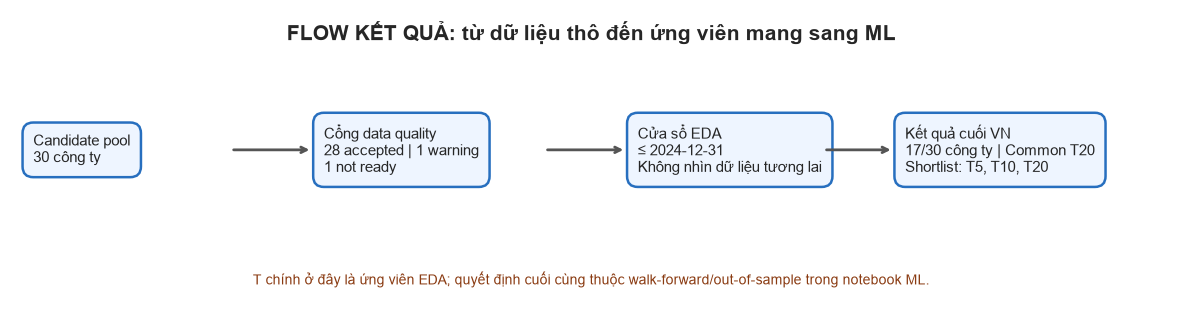

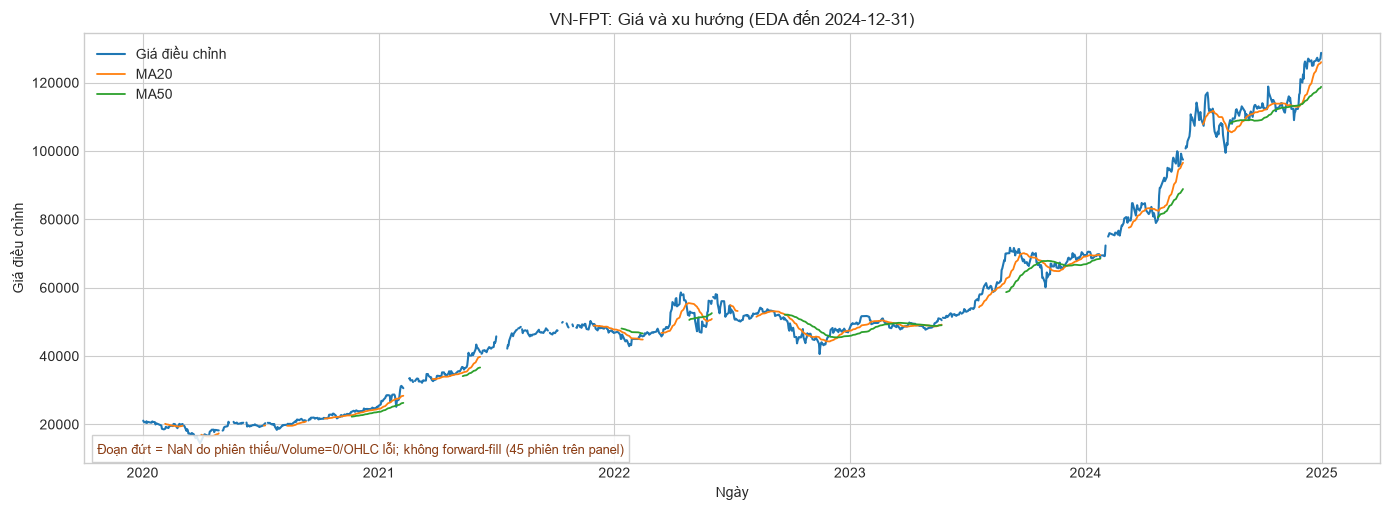

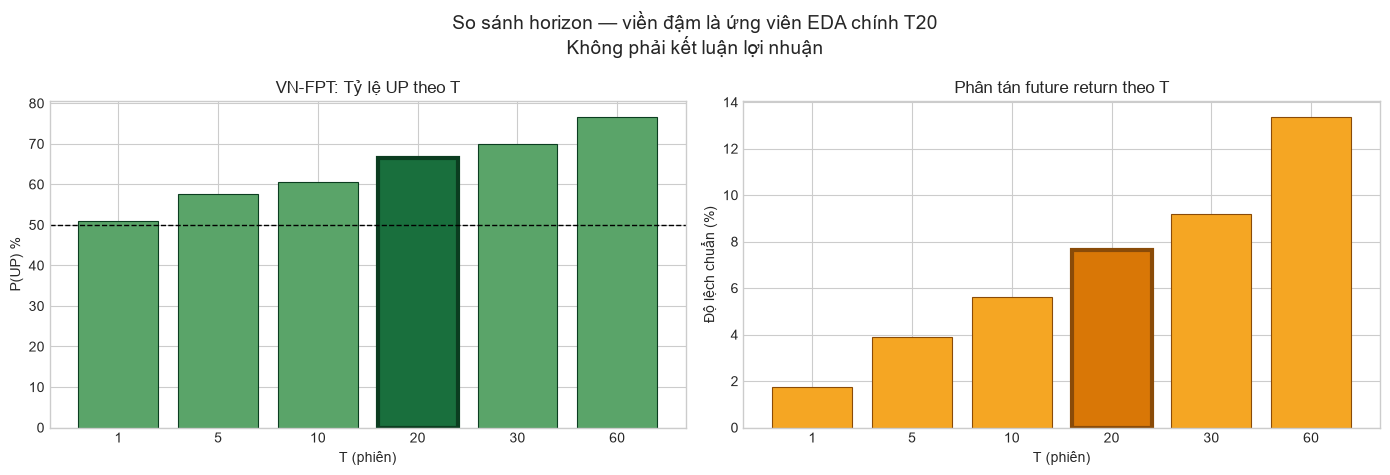

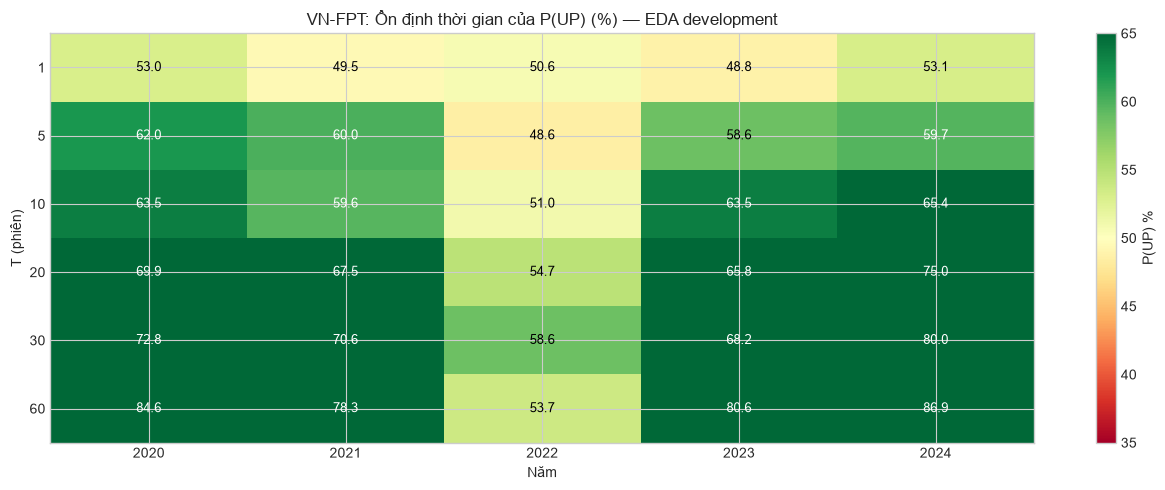

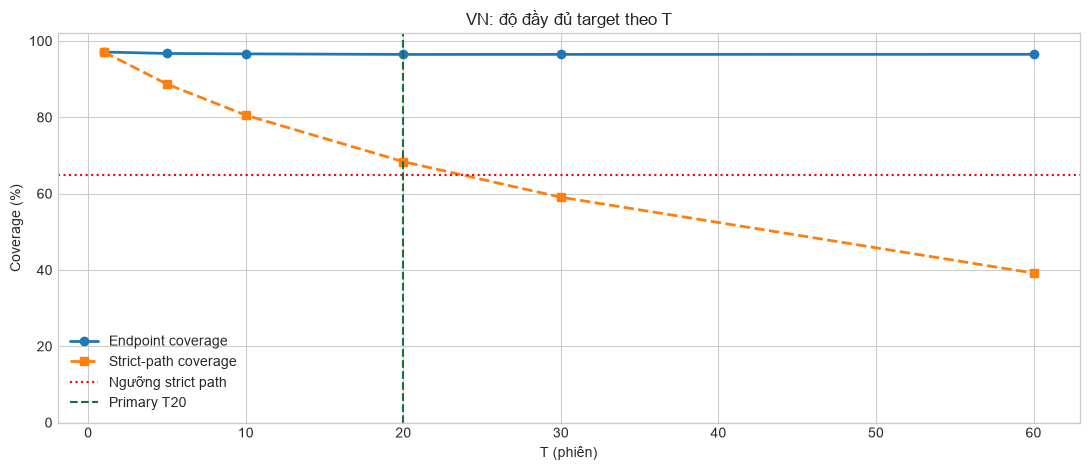

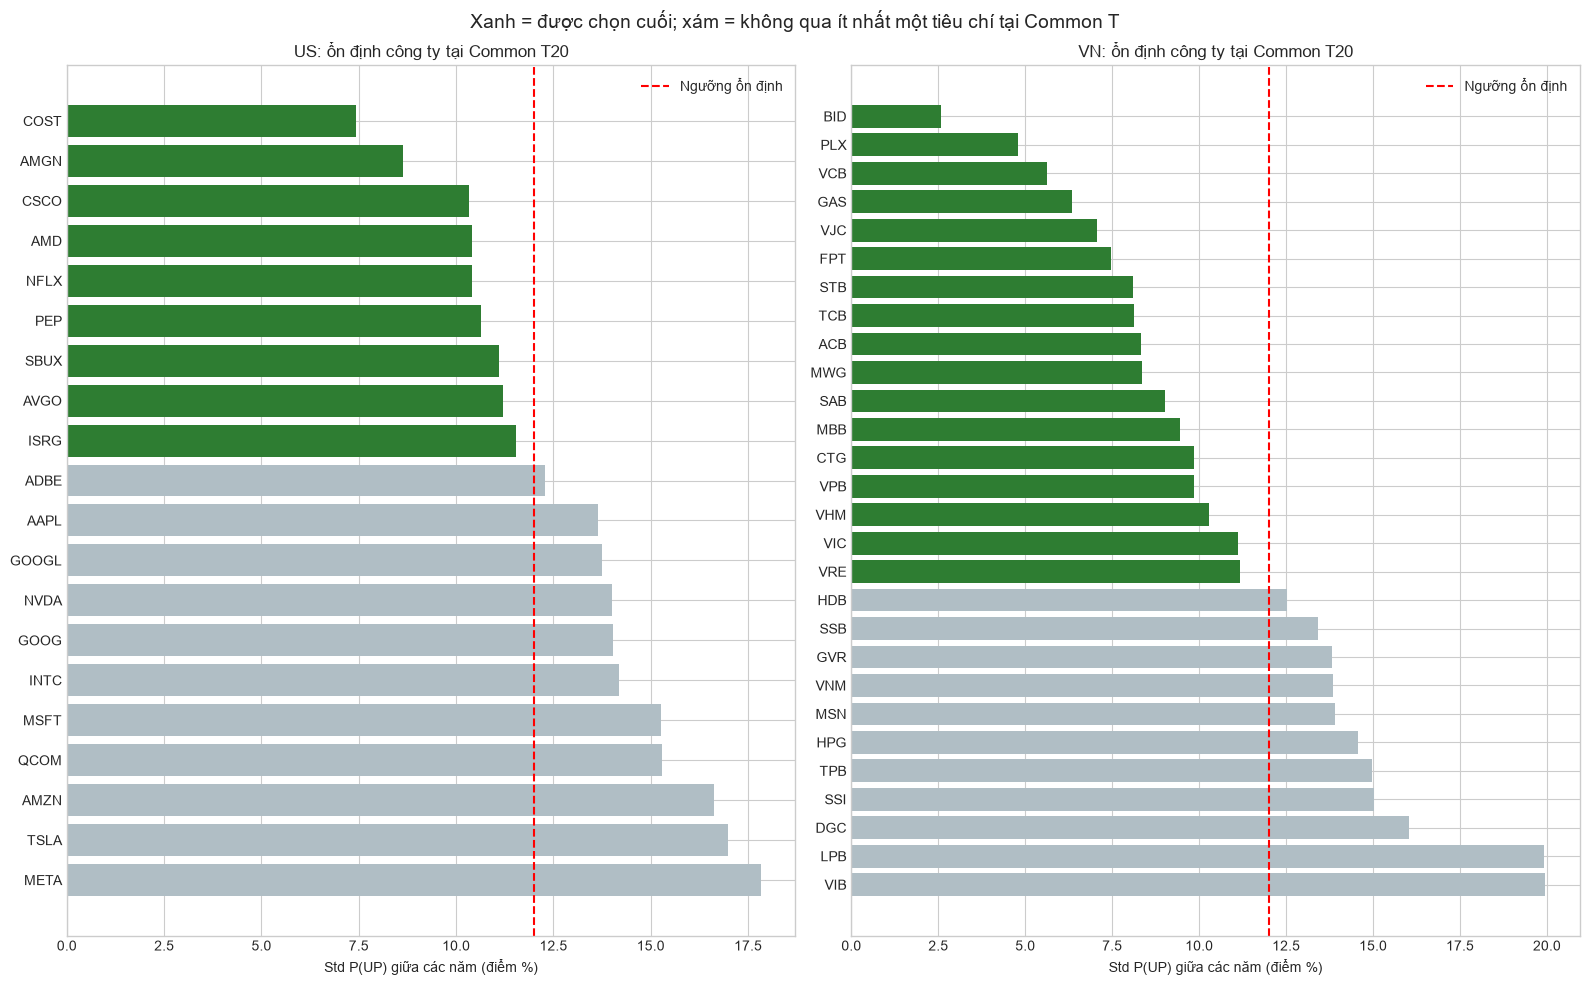

,Market,RawCandidates,PassedDataQuality,SelectedCompanies,CommonT,HorizonShortlist,SelectedTickers,NotSelectedTickers,Interpretation
0,US,20,20,9,20,"T1, T5, T10, T20","AMD, AMGN, AVGO, COST, CSCO, ISRG, NFLX, PEP, ...","AAPL, ADBE, AMZN, GOOG, GOOGL, INTC, META, MSF...",Dùng CommonT làm cấu hình đầu tiên trong ML; v...
1,VN,30,28,17,20,"T5, T10, T20","ACB, BID, CTG, FPT, GAS, MBB, MWG, PLX, SAB, S...","DGC, GVR, HDB, HPG, LPB, MSN, SHB, SSB, SSI, T...",Dùng CommonT làm cấu hình đầu tiên trong ML; v...


,Market,Ticker,CommonT,TargetCoverage,StrictPathCoverage,P(UP),PUPYearStd,MinorityClassShare,FinalStatus,FinalDecisionReason
2,US,AMD,20,1.0000,1.0000,0.5159,0.1041,0.4841,SELECTED_FOR_ML,Được chọn
3,US,AMGN,20,1.0000,1.0000,0.4865,0.0863,0.4865,SELECTED_FOR_ML,Được chọn
5,US,AVGO,20,1.0000,1.0000,0.6860,0.1121,0.3140,SELECTED_FOR_ML,Được chọn
6,US,COST,20,1.0000,1.0000,0.6645,0.0742,0.3355,SELECTED_FOR_ML,Được chọn
7,US,CSCO,20,1.0000,1.0000,0.5882,0.1033,0.4118,SELECTED_FOR_ML,Được chọn
11,US,ISRG,20,1.0000,1.0000,0.6041,0.1155,0.3959,SELECTED_FOR_ML,Được chọn
14,US,NFLX,20,1.0000,1.0000,0.6145,0.1042,0.3855,SELECTED_FOR_ML,Được chọn
16,US,PEP,20,1.0000,1.0000,0.5779,0.1063,0.4221,SELECTED_FOR_ML,Được chọn
18,US,SBUX,20,1.0000,1.0000,0.5199,0.1111,0.4801,SELECTED_FOR_ML,Được chọn
0,US,AAPL,20,1.0000,1.0000,0.6192,0.1366,0.3808,NOT_SELECTED,P(UP) biến động mạnh giữa các năm


In [8]:
selected_market = CONFIG["SELECTED_MARKET"]
selected_ticker = CONFIG["SELECTED_TICKER"]
market_rec = EDA_RECOMMENDATION.set_index("Market").loc[selected_market]
primary_t = int(market_rec["PrimaryT"])

# 1) Flow chart kết luận.
market_quality = COMPANY_QUALITY[COMPANY_QUALITY["Market"].eq(selected_market)]
status_counts = market_quality.groupby("CompanyStatus").size().to_dict()
total_candidates = market_quality["Ticker"].nunique()
accepted_count = status_counts.get("AcceptedForML", 0)
warning_count = status_counts.get("AcceptedWithWarning", 0)
not_ready_count = status_counts.get("NeedMoreOrBetterData", 0)
market_final = FINAL_PROJECT_RECOMMENDATION.set_index("Market").loc[selected_market]

fig, ax = plt.subplots(figsize=(15, 3.8))
ax.axis("off")
boxes = [
    (0.02, f"Candidate pool\n{total_candidates} công ty"),
    (0.27, f"Cổng data quality\n{accepted_count} accepted | {warning_count} warning\n{not_ready_count} not ready"),
    (0.54, f"Cửa sổ EDA\n≤ {CONFIG['EDA_DECISION_END']}\nKhông nhìn dữ liệu tương lai"),
    (0.77, f"Kết quả cuối {selected_market}\n{market_final['SelectedCompanies']}/{market_final['RawCandidates']} công ty | Common T{primary_t}\nShortlist: {market_rec['ShortlistedT']}"),
]
for x, label in boxes:
    ax.text(x, 0.52, label, transform=ax.transAxes, ha="left", va="center", fontsize=11,
            bbox=dict(boxstyle="round,pad=0.7", facecolor="#eef5ff", edgecolor="#276FBF", linewidth=1.8))
for x1, x2 in [(0.19, 0.26), (0.46, 0.53), (0.70, 0.76)]:
    ax.annotate("", xy=(x2, 0.52), xytext=(x1, 0.52), xycoords=ax.transAxes,
                arrowprops=dict(arrowstyle="->", lw=2, color="#555555"))
ax.text(0.5, 0.96, "FLOW KẾT QUẢ: từ dữ liệu thô đến ứng viên mang sang ML", transform=ax.transAxes,
        ha="center", va="top", fontsize=15, fontweight="bold")
ax.text(0.5, 0.06, "T chính ở đây là ứng viên EDA; quyết định cuối cùng thuộc walk-forward/out-of-sample trong notebook ML.",
        transform=ax.transAxes, ha="center", fontsize=10, color="#8a3b12")
plt.show()

# 2) Giá và xu hướng của ticker được chọn, chỉ trên cửa sổ quyết định EDA.
selected = FEATURED[
    FEATURED["Market"].eq(selected_market)
    & FEATURED["Ticker"].eq(selected_ticker)
    & FEATURED["Date"].le(EDA_DECISION_END)
].sort_values("Date")

fig, ax = plt.subplots(figsize=(14, 5.2))
ax.plot(selected["Date"], selected["AdjCloseAnalysis"], label="Giá điều chỉnh", linewidth=1.5)
ax.plot(selected["Date"], selected["MA20"], label="MA20", linewidth=1.3)
ax.plot(selected["Date"], selected["MA50"], label="MA50", linewidth=1.3)
ax.set(title=f"{selected_market}-{selected_ticker}: Giá và xu hướng (EDA đến {CONFIG['EDA_DECISION_END']})",
       xlabel="Ngày", ylabel="Giá điều chỉnh")
invalid_sessions = int((~selected["ObservationEligible"]).sum())
ax.text(
    0.01, 0.02,
    f"Đoạn đứt = NaN do phiên thiếu/Volume=0/OHLC lỗi; không forward-fill ({invalid_sessions} phiên trên panel)",
    transform=ax.transAxes, fontsize=9, color="#8A3B12",
    bbox=dict(facecolor="white", alpha=0.85, edgecolor="#C7C7C7"),
)
ax.legend()
fig.tight_layout()
plt.show()

# 3) So sánh P(UP) và độ phân tán return giống flow đọc của notebook cũ.
ticker_h = COMPANY_T_DIAGNOSTICS[
    COMPANY_T_DIAGNOSTICS["Market"].eq(selected_market)
    & COMPANY_T_DIAGNOSTICS["Ticker"].eq(selected_ticker)
].sort_values("T")
bar_colors = ["#196F3D" if int(t) == primary_t else "#5AA469" for t in ticker_h["T"]]
edge_widths = [3 if int(t) == primary_t else 0.8 for t in ticker_h["T"]]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
bars = axes[0].bar(ticker_h["T"].astype(str), ticker_h["P(UP)"] * 100, color=bar_colors,
                   edgecolor="#0B3D20", linewidth=edge_widths)
axes[0].axhline(50, color="black", linestyle="--", linewidth=1)
axes[0].set(title=f"{selected_market}-{selected_ticker}: Tỷ lệ UP theo T", xlabel="T (phiên)", ylabel="P(UP) %")

disp_colors = ["#D97706" if int(t) == primary_t else "#F5A623" for t in ticker_h["T"]]
axes[1].bar(ticker_h["T"].astype(str), ticker_h["FutureReturnStd"] * 100, color=disp_colors,
            edgecolor="#8A4B08", linewidth=edge_widths)
axes[1].set(title="Phân tán future return theo T", xlabel="T (phiên)", ylabel="Độ lệch chuẩn (%)")
fig.suptitle(f"So sánh horizon — viền đậm là ứng viên EDA chính T{primary_t}\nKhông phải kết luận lợi nhuận", fontsize=14)
fig.tight_layout()
plt.show()

# 4) Heatmap P(UP) theo năm cho ticker được chọn.
heat_rows = []
base_ticker = EDA_CANDIDATES[
    EDA_CANDIDATES["Market"].eq(selected_market) & EDA_CANDIDATES["Ticker"].eq(selected_ticker)
]
for t in CONFIG["HORIZONS"]:
    valid = base_ticker[
        base_ticker["DateStatus"].eq("SessionHealthy")
        & base_ticker["ObservationEligible"]
        & base_ticker[f"TargetEligible_{t}"]
    ].copy()
    valid["Year"] = valid["Date"].dt.year
    for year, value in valid.groupby("Year")[f"TargetUp_{t}"].mean().items():
        heat_rows.append({"T": t, "Year": year, "P(UP)": value * 100})
heat = pd.DataFrame(heat_rows).pivot(index="T", columns="Year", values="P(UP)").reindex(CONFIG["HORIZONS"])

fig, ax = plt.subplots(figsize=(13, 5.0))
image = ax.imshow(heat.to_numpy(), aspect="auto", cmap="RdYlGn", vmin=35, vmax=65)
ax.set_xticks(range(len(heat.columns)), labels=heat.columns)
ax.set_yticks(range(len(heat.index)), labels=heat.index)
ax.set_xlabel("Năm")
ax.set_ylabel("T (phiên)")
ax.set_title(f"{selected_market}-{selected_ticker}: Ổn định thời gian của P(UP) (%) — EDA development")
for i in range(len(heat.index)):
    for j in range(len(heat.columns)):
        value = heat.iloc[i, j]
        if pd.notna(value):
            ax.text(j, i, f"{value:.1f}", ha="center", va="center", fontsize=9,
                    color="white" if value < 41 or value > 59 else "black")
fig.colorbar(image, ax=ax, label="P(UP) %")
fig.tight_layout()
plt.show()

# 5) Endpoint coverage và strict-path coverage: lý do T dài không tự động tốt hơn.
market_h = HORIZON_DIAGNOSTICS[HORIZON_DIAGNOSTICS["Market"].eq(selected_market)].sort_values("T")
fig, ax = plt.subplots(figsize=(11, 4.8))
ax.plot(market_h["T"], market_h["TargetCoverage"] * 100, marker="o", linewidth=2, label="Endpoint coverage")
ax.plot(market_h["T"], market_h["StrictPathCoverage"] * 100, marker="s", linestyle="--", linewidth=2, label="Strict-path coverage")
ax.axhline(CONFIG["MIN_STRICT_PATH_COVERAGE_FOR_T"] * 100, color="red", linestyle=":", label="Ngưỡng strict path")
ax.axvline(primary_t, color="#196F3D", linestyle="--", linewidth=1.5, label=f"Primary T{primary_t}")
ax.set(title=f"{selected_market}: độ đầy đủ target theo T", xlabel="T (phiên)", ylabel="Coverage (%)", ylim=(0, 102))
ax.legend()
fig.tight_layout()
plt.show()

# 6) Bảng trả lời trực tiếp: chọn T nào và giữ công ty nào.
company_view = COMPANY_QUALITY[[
    "Market", "Ticker", "HistoryYears", "CoverageOnHealthySessions",
    "MinimumYearlyCoverage", "MaximumConsecutiveInvalidGap", "CompanyStatus", "StatusReason"
]].copy()
company_view = company_view.merge(COMPANY_T_RECOMMENDATION, on=["Market", "Ticker"], how="left")
# 7) Độ ổn định từng công ty tại Common T: màu xanh là danh sách cuối.
markets = FINAL_PROJECT_RECOMMENDATION["Market"].tolist()
fig, axes = plt.subplots(1, len(markets), figsize=(16, 10), squeeze=False)
for ax, market in zip(axes[0], markets):
    data = FINAL_COMPANY_SELECTION[
        FINAL_COMPANY_SELECTION["Market"].eq(market) & FINAL_COMPANY_SELECTION["PassDataQuality"]
    ].sort_values("PUPYearStd", ascending=False)
    colors = np.where(data["FinalSelected"], "#2E7D32", "#B0BEC5")
    ax.barh(data["Ticker"], data["PUPYearStd"] * 100, color=colors)
    ax.axvline(CONFIG["MAX_COMPANY_PUP_YEAR_STD_AT_COMMON_T"] * 100,
               color="red", linestyle="--", label="Ngưỡng ổn định")
    common_t = int(FINAL_PROJECT_RECOMMENDATION.set_index("Market").loc[market, "CommonT"])
    ax.set(title=f"{market}: ổn định công ty tại Common T{common_t}", xlabel="Std P(UP) giữa các năm (điểm %)")
    ax.legend()
fig.suptitle("Xanh = được chọn cuối; xám = không qua ít nhất một tiêu chí tại Common T", fontsize=14)
fig.tight_layout()
plt.show()

display(FINAL_PROJECT_RECOMMENDATION)
final_company_view = FINAL_COMPANY_SELECTION.sort_values(
    ["Market", "FinalSelected", "Ticker"], ascending=[True, False, True]
)[[
    "Market", "Ticker", "CommonT", "TargetCoverage", "StrictPathCoverage", "P(UP)",
    "PUPYearStd", "MinorityClassShare", "FinalStatus", "FinalDecisionReason"
]]
display(final_company_view)

## 8. Kiểm thử tự động

Test bảo vệ cả phần xử lý session lẫn logic kết luận:

- Session không bị mất khi có ticker gap hoặc market-wide gap.
- `Volume=0` không được xem là observation hợp lệ.
- Endpoint target cách đúng T session; rolling window không tự bỏ qua gap.
- Công ty và T được chọn chỉ dùng dữ liệu đến `EDA_DECISION_END`.
- `PrimaryT` phải nằm trong shortlist khi shortlist tồn tại.

Notebook dừng bằng assertion nếu có test thất bại.

In [9]:
TEST_ROWS = []
def check(name, condition, detail=""):
    TEST_ROWS.append({"Test": name, "Result": "PASS" if bool(condition) else "FAIL", "Detail": detail})

check("Có CSV đầu vào", len(CSV_FILES) > 0, f"files={len(CSV_FILES)}")
check("Tất cả CSV nạp thành công", len(LOAD_FAILURES) == 0, f"failures={len(LOAD_FAILURES)}")
check("Panel không trùng market-ticker-date", not PANEL.duplicated(["Market", "Ticker", "Date"]).any())
check("Panel tăng theo thời gian", all(g["Date"].is_monotonic_increasing for _, g in PANEL.groupby(["Market", "Ticker"])))
check("Mọi panel date thuộc canonical calendar", all(set(g["Date"]).issubset(calendar_sets[market]) for market, g in PANEL.groupby("Market")))
check("Volume=0 không ObservationEligible", not PANEL.loc[PANEL["VolumeZero"].fillna(False), "ObservationEligible"].any())
check("Analytical volume luôn dương khi tồn tại", PANEL["VolumeAnalysis"].dropna().gt(0).all())
check("Raw volume dương ngoài calendar bằng 0", int(OFF_CALENDAR["Volume"].gt(0).sum()) == 0, f"count={int(OFF_CALENDAR['Volume'].gt(0).sum())}")
check("Market-wide gap vẫn được giữ trên panel", set(MARKET_BREADTH.loc[MARKET_BREADTH["DateStatus"].eq("MarketWideDataGap"), "Date"]).issubset(set(PANEL["Date"])))

endpoint_ok = True
for t in CONFIG["HORIZONS"]:
    eligible = FEATURED[f"TargetEligible_{t}"]
    endpoint_ok &= bool((FEATURED.loc[eligible, f"EndpointSession_{t}"] - FEATURED.loc[eligible, "SessionNumber"]).eq(t).all())
check("Mọi target endpoint cách đúng T session", endpoint_ok)

syn = pd.Series(np.arange(30, dtype=float))
syn.iloc[10] = np.nan
syn_ma = syn.rolling(20, min_periods=20).mean()
check("Rolling strict không bỏ qua gap", syn_ma.iloc[19:30].isna().all())

# Future mutation must not change features before the mutation date.
syn_price = pd.Series(100 + np.arange(80, dtype=float))
base_ma = syn_price.rolling(20, min_periods=20).mean()
changed = syn_price.copy(); changed.iloc[-1] *= 10
changed_ma = changed.rolling(20, min_periods=20).mean()
check("Feature quá khứ không nhìn tương lai", base_ma.iloc[:-1].equals(changed_ma.iloc[:-1]))

check("EDA không nhìn sau decision end", EDA_CANDIDATES["Date"].max() <= EDA_DECISION_END,
      f"max={EDA_CANDIDATES['Date'].max().date()}, cutoff={EDA_DECISION_END.date()}")
check("Company quality dùng decision end", COMPANY_QUALITY["DecisionEnd"].dropna().le(EDA_DECISION_END).all())

primary_in_shortlist = True
for rec in EDA_RECOMMENDATION.itertuples(index=False):
    shortlist = HORIZON_DIAGNOSTICS[
        HORIZON_DIAGNOSTICS["Market"].eq(rec.Market) & HORIZON_DIAGNOSTICS["EDAShortlist"]
    ]["T"].tolist()
    if shortlist:
        primary_in_shortlist &= rec.PrimaryT in shortlist
check("PrimaryT nằm trong shortlist", primary_in_shortlist)
check("EDA candidates chỉ gồm AcceptedForML", set(EDA_CANDIDATES[["Market", "Ticker"]].drop_duplicates().itertuples(index=False, name=None))
      == set(accepted.itertuples(index=False, name=None)))

check("Final selection chỉ lấy AcceptedForML",
      FINAL_COMPANY_SELECTION.loc[FINAL_COMPANY_SELECTION["FinalSelected"], "CompanyStatus"].eq("AcceptedForML").all())
final_pass_cols = [
    "PassDataQuality", "PassTargetCoverage", "PassStrictPathCoverage",
    "PassTemporalStability", "PassTargetBalance",
]
check("Mọi công ty được chọn qua toàn bộ tiêu chí",
      FINAL_COMPANY_SELECTION.loc[FINAL_COMPANY_SELECTION["FinalSelected"], final_pass_cols].all(axis=None))
common_t_matches = all(
    int(row.CommonT) == int(EDA_RECOMMENDATION.set_index("Market").loc[row.Market, "PrimaryT"])
    for row in FINAL_PROJECT_RECOMMENDATION.itertuples(index=False)
)
check("Common T khớp PrimaryT theo market", common_t_matches)
check("Mọi raw candidate có quyết định cuối",
      FINAL_COMPANY_SELECTION[["Market", "Ticker"]].drop_duplicates().shape[0] == COMPANY_QUALITY.shape[0])

TEST_RESULTS = pd.DataFrame(TEST_ROWS)
display(TEST_RESULTS)
print(TEST_RESULTS.to_string(index=False))
print("SUMMARY:", TEST_RESULTS["Result"].value_counts().to_dict())
assert TEST_RESULTS["Result"].eq("PASS").all(), "Có test thất bại; xem TEST_RESULTS trước khi dùng output."


,Test,Result,Detail
0,Có CSV đầu vào,PASS,files=50
1,Tất cả CSV nạp thành công,PASS,failures=0
2,Panel không trùng market-ticker-date,PASS,
3,Panel tăng theo thời gian,PASS,
4,Mọi panel date thuộc canonical calendar,PASS,
5,Volume=0 không ObservationEligible,PASS,
6,Analytical volume luôn dương khi tồn tại,PASS,
7,Raw volume dương ngoài calendar bằng 0,PASS,count=0
8,Market-wide gap vẫn được giữ trên panel,PASS,
9,Mọi target endpoint cách đúng T session,PASS,


                                      Test Result                            Detail
                            Có CSV đầu vào   PASS                          files=50
                 Tất cả CSV nạp thành công   PASS                        failures=0
      Panel không trùng market-ticker-date   PASS                                  
                 Panel tăng theo thời gian   PASS                                  
   Mọi panel date thuộc canonical calendar   PASS                                  
        Volume=0 không ObservationEligible   PASS                                  
  Analytical volume luôn dương khi tồn tại   PASS                                  
    Raw volume dương ngoài calendar bằng 0   PASS                           count=0
   Market-wide gap vẫn được giữ trên panel   PASS                                  
   Mọi target endpoint cách đúng T session   PASS                                  
           Rolling strict không bỏ qua gap   PASS                           

## 9. Xuất workbook kiểm tra

Workbook chứa cả dữ liệu audit lẫn ba bảng trả lời trực tiếp:

- `EDA_Decision`: T chính, shortlist và danh sách công ty theo trạng thái.
- `Company_Quality`: công ty nào nên giữ/cảnh báo/tìm thêm dữ liệu.
- `Horizon_Diagnostics`: vì sao mỗi T qua hoặc không qua ngưỡng.

Dữ liệu raw không bị sửa. Workbook được ghi vào `outputs/test/Session_Aligned_EDA_Test.xlsx`.

In [10]:
EXPORT_PATH = OUT_DIR / "Session_Aligned_EDA_Test.xlsx"

def write_eda_workbook(output_path):
    config_table = pd.DataFrame({"Parameter": list(CONFIG), "Value": [str(v) for v in CONFIG.values()]})
    panel_export_cols = [
        "Market", "Ticker", "Date", "RawRowPresent", "DateStatus", "ObservationStatus",
        "RowCoverageShare", "ValidPriceShare", "PositiveVolumeShare", "OpenAnalysis",
        "HighAnalysis", "LowAnalysis", "CloseAnalysis", "AdjCloseAnalysis", "VolumeAnalysis",
        "Return_1", "MA20", "RSI14"
    ]
    with pd.ExcelWriter(output_path, engine="xlsxwriter", datetime_format="yyyy-mm-dd") as writer:
        config_table.to_excel(writer, sheet_name="Config", index=False)
        FINAL_PROJECT_RECOMMENDATION.to_excel(writer, sheet_name="Final_Recommendation", index=False)
        FINAL_COMPANY_SELECTION.to_excel(writer, sheet_name="Final_Company_Selection", index=False)
        EDA_DECISION_SUMMARY.to_excel(writer, sheet_name="EDA_Decision", index=False)
        EDA_RECOMMENDATION.to_excel(writer, sheet_name="T_Recommendation", index=False)
        CALENDAR_AUDIT.to_excel(writer, sheet_name="Calendar_Audit", index=False)
        FILE_AUDIT.to_excel(writer, sheet_name="File_Audit", index=False)
        ELIGIBILITY.to_excel(writer, sheet_name="Eligibility", index=False)
        MARKET_BREADTH.to_excel(writer, sheet_name="Market_Breadth", index=False)
        STATUS_COUNTS.to_excel(writer, sheet_name="Status_Counts", index=False)
        COMPANY_QUALITY.to_excel(writer, sheet_name="Company_Quality", index=False)
        HORIZON_DIAGNOSTICS.to_excel(writer, sheet_name="Horizon_Diagnostics", index=False)
        HORIZON_DECISION_TABLE.to_excel(writer, sheet_name="Horizon_Decision", index=False)
        SELECTED_HEATMAP_DATA.to_excel(writer, sheet_name="Selected_Heatmap_Data", index=False)
        COMPANY_T_DIAGNOSTICS.to_excel(writer, sheet_name="Company_T_Diagnostics", index=False)
        TEST_RESULTS.to_excel(writer, sheet_name="Tests", index=False)
        OFF_CALENDAR.to_excel(writer, sheet_name="Off_Calendar_Rows", index=False)
        FEATURED[panel_export_cols].to_excel(writer, sheet_name="Aligned_Panel", index=False)

if CONFIG["EXPORT_XLSX"]:
    try:
        write_eda_workbook(EXPORT_PATH)
    except PermissionError:
        timestamp = pd.Timestamp.now().strftime("%Y%m%d_%H%M%S")
        EXPORT_PATH = OUT_DIR / f"Session_Aligned_EDA_Test_{timestamp}.xlsx"
        print("Workbook mặc định đang mở/được khóa; xuất sang file mới để không làm notebook thất bại.")
        write_eda_workbook(EXPORT_PATH)
    print(f"Exported: {EXPORT_PATH}")
else:
    print("EXPORT_XLSX=False — không tạo workbook")

Exported: C:\Users\DELL\projects\P4AIDS - Stock\outputs\test\Session_Aligned_EDA_Test.xlsx


## 10. Heatmap của toàn bộ công ty được chọn

Phần này có hai mức đọc:

1. **Heatmap so sánh tại Common T:** hàng là công ty, cột là năm. Đây là chart nên xem trước vì mọi công ty dùng cùng một T và cùng thang màu.
2. **Heatmap chi tiết từng công ty:** giống heatmap FPT, hàng là toàn bộ candidate T và cột là năm. Các grid này được bật/tắt bằng `SHOW_DETAILED_SELECTED_HEATMAPS`.

Tất cả chart dùng cùng thang màu 35–65%. Màu xanh hơn chỉ có nghĩa tỷ lệ UP cao hơn; vẫn phải nhìn độ đều màu giữa các năm, strict-path coverage và số target. Một ô xanh đậm không tự động làm T đó trở thành Common T.

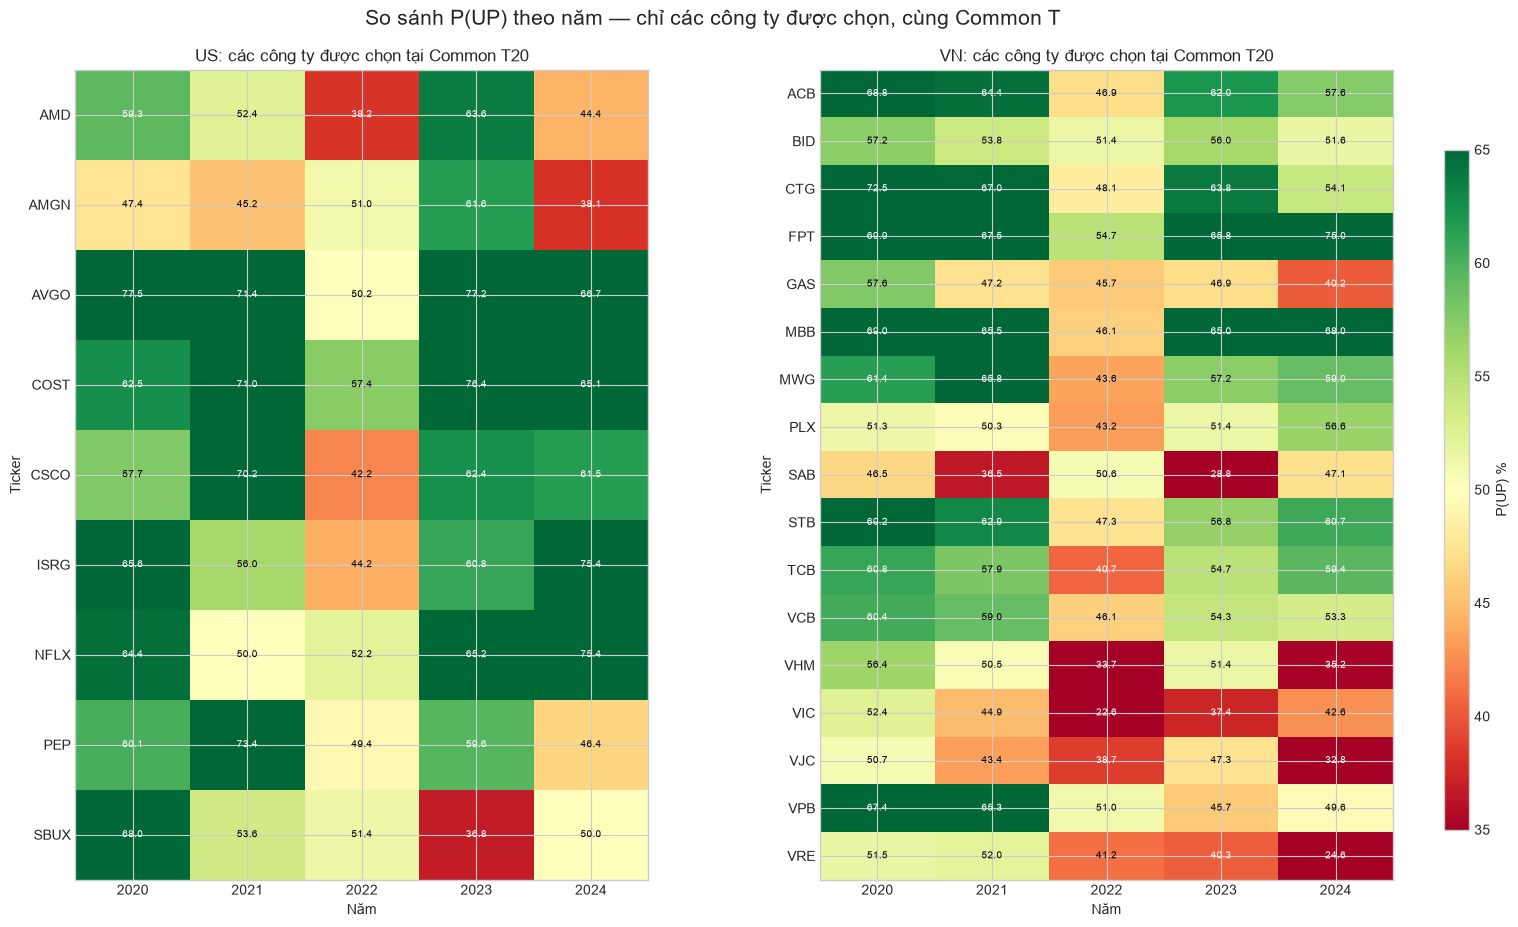

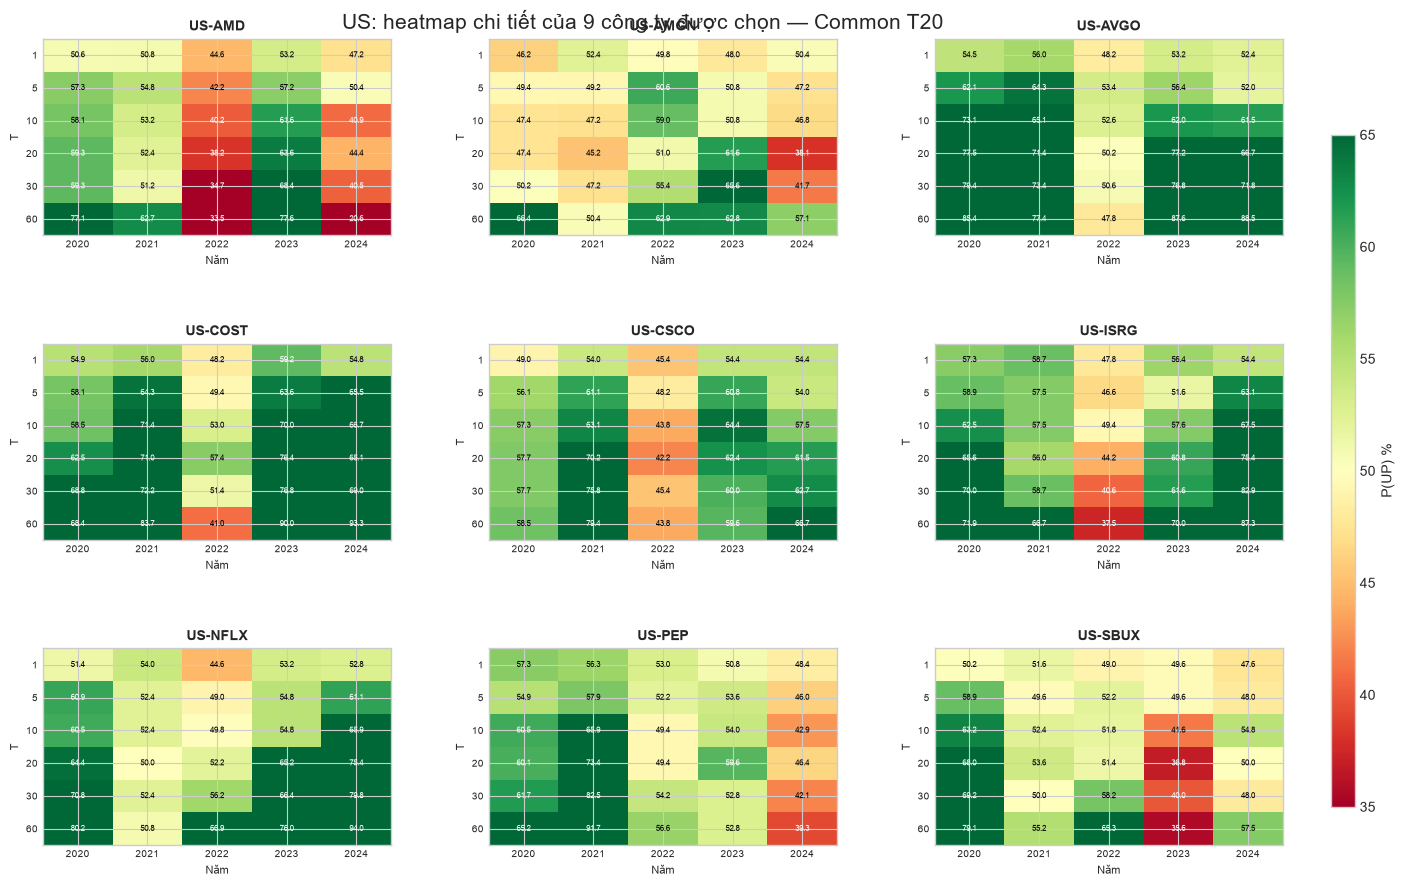

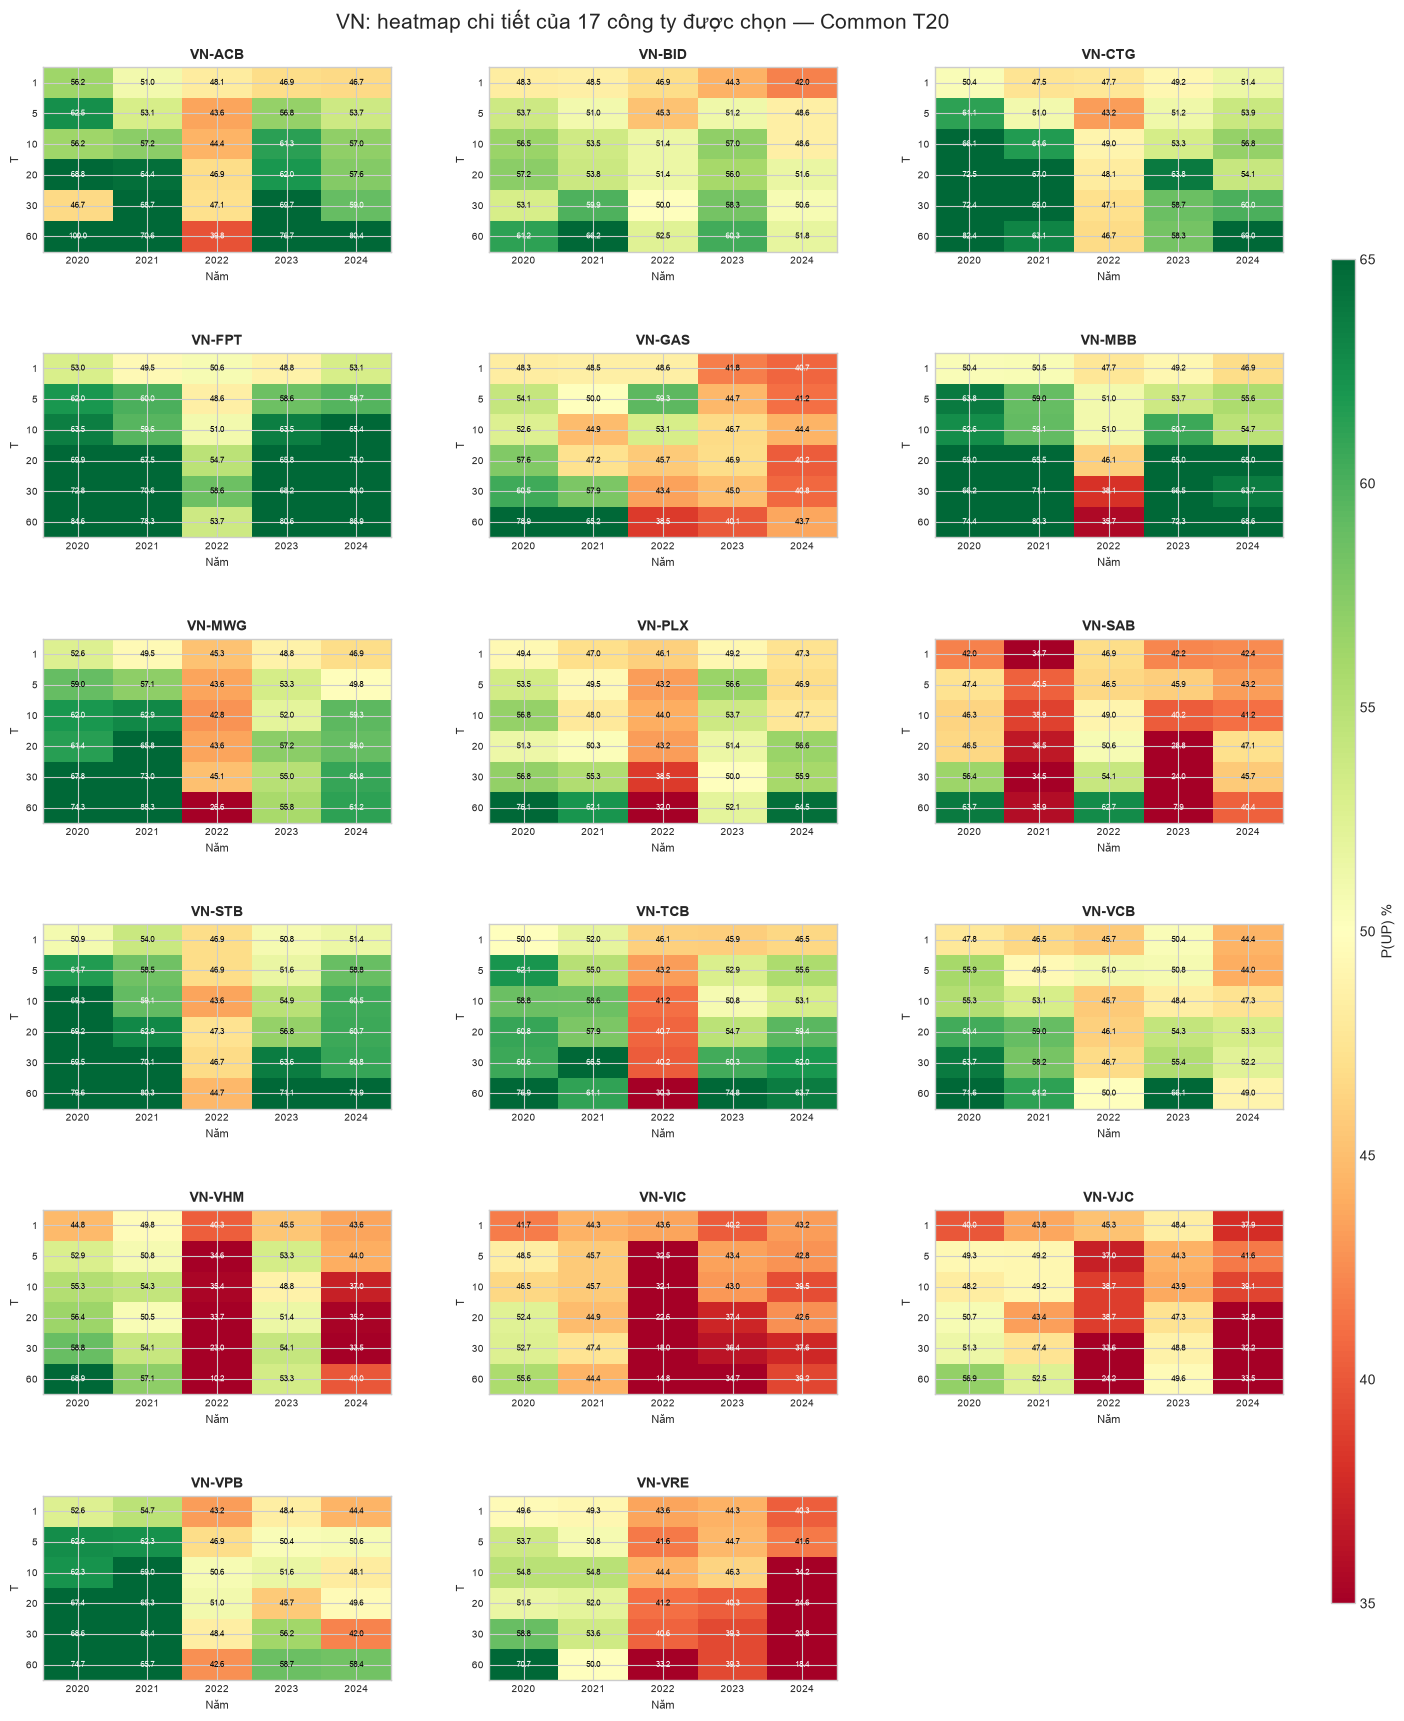

In [11]:
def annotate_heatmap(ax, matrix, fontsize=8):
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            value = matrix.iloc[i, j]
            if pd.notna(value):
                ax.text(j, i, f"{value:.1f}", ha="center", va="center", fontsize=fontsize,
                        color="white" if value < 41 or value > 59 else "black")

# A. So sánh tất cả công ty tại đúng Common T.
markets = FINAL_PROJECT_RECOMMENDATION["Market"].tolist()
fig, axes = plt.subplots(1, len(markets), figsize=(17, 10), squeeze=False)
last_image = None
for ax, market in zip(axes[0], markets):
    common_t = int(FINAL_PROJECT_RECOMMENDATION.set_index("Market").loc[market, "CommonT"])
    data = SELECTED_HEATMAP_DATA[
        SELECTED_HEATMAP_DATA["Market"].eq(market) & SELECTED_HEATMAP_DATA["IsCommonT"]
    ]
    matrix = (data.pivot(index="Ticker", columns="Year", values="P(UP)") * 100).sort_index()
    last_image = ax.imshow(matrix.to_numpy(), aspect="auto", cmap="RdYlGn", vmin=35, vmax=65)
    ax.set_xticks(range(len(matrix.columns)), labels=matrix.columns)
    ax.set_yticks(range(len(matrix.index)), labels=matrix.index)
    ax.set(title=f"{market}: các công ty được chọn tại Common T{common_t}", xlabel="Năm", ylabel="Ticker")
    annotate_heatmap(ax, matrix, fontsize=7)
color_ax = fig.add_axes([0.93, 0.16, 0.015, 0.68])
fig.colorbar(last_image, cax=color_ax, label="P(UP) %")
fig.suptitle("So sánh P(UP) theo năm — chỉ các công ty được chọn, cùng Common T", fontsize=15)
fig.subplots_adjust(top=0.92, right=0.90, wspace=0.30)
plt.show()

# B. Grid chi tiết: mỗi subplot là heatmap T × năm của một công ty được chọn.
if CONFIG["SHOW_DETAILED_SELECTED_HEATMAPS"]:
    for market in markets:
        tickers = FINAL_COMPANY_SELECTION.loc[
            FINAL_COMPANY_SELECTION["Market"].eq(market) & FINAL_COMPANY_SELECTION["FinalSelected"], "Ticker"
        ].sort_values().tolist()
        ncols = 3
        nrows = int(np.ceil(len(tickers) / ncols))
        fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3.2 * nrows), squeeze=False)
        last_image = None
        for ax, ticker in zip(axes.ravel(), tickers):
            data = SELECTED_HEATMAP_DATA[
                SELECTED_HEATMAP_DATA["Market"].eq(market) & SELECTED_HEATMAP_DATA["Ticker"].eq(ticker)
            ]
            matrix = (data.pivot(index="T", columns="Year", values="P(UP)") * 100).reindex(CONFIG["HORIZONS"])
            last_image = ax.imshow(matrix.to_numpy(), aspect="auto", cmap="RdYlGn", vmin=35, vmax=65)
            ax.set_xticks(range(len(matrix.columns)), labels=matrix.columns, fontsize=7)
            ax.set_yticks(range(len(matrix.index)), labels=matrix.index, fontsize=7)
            ax.set_title(f"{market}-{ticker}", fontsize=10, fontweight="bold")
            ax.set_xlabel("Năm", fontsize=8)
            ax.set_ylabel("T", fontsize=8)
            annotate_heatmap(ax, matrix, fontsize=6)
        for ax in axes.ravel()[len(tickers):]:
            ax.axis("off")
        common_t = int(FINAL_PROJECT_RECOMMENDATION.set_index("Market").loc[market, "CommonT"])
        color_ax = fig.add_axes([0.93, 0.15, 0.015, 0.70])
        fig.colorbar(last_image, cax=color_ax, label="P(UP) %")
        fig.suptitle(
            f"{market}: heatmap chi tiết của {len(tickers)} công ty được chọn — Common T{common_t}",
            fontsize=15,
        )
        fig.subplots_adjust(top=0.95, right=0.90, hspace=0.55, wspace=0.28)
        plt.show()
else:
    print("Heatmap chi tiết đang tắt. Đặt CONFIG['SHOW_DETAILED_SELECTED_HEATMAPS']=True rồi Run All để hiển thị.")

## 11. KẾT LUẬN CUỐI CÙNG — đọc cell này sau mỗi lần chạy

Cell cuối dưới đây được sinh động từ dữ liệu và CONFIG, không viết cứng tên công ty hay T.

Mỗi thị trường có:

- `SelectedCompanies / RawCandidates`: số công ty cuối cùng trên tổng CSV đầu vào.
- `SelectedTickers`: danh sách cụ thể nên đưa sang notebook ML.
- `CommonT`: một T chung đề xuất cho toàn bộ danh sách đó.
- `HorizonShortlist`: các T vẫn nên so sánh trong walk-forward để kiểm chứng Common T.
- `NotSelectedTickers`: công ty chưa qua cổng hiện tại; xem `FinalDecisionReason` để biết cần thêm data hay nới ngưỡng nào.

Nếu thay CSV, `HORIZONS` hoặc bất kỳ ngưỡng nào trong CONFIG, kết luận dưới đây sẽ tự thay đổi sau khi chạy lại toàn bộ notebook.

In [12]:
display(FINAL_PROJECT_RECOMMENDATION)

print("=" * 100)
print("KẾT LUẬN ĐỀ XUẤT CHO GIAI ĐOẠN ML")
print("=" * 100)
for row in FINAL_PROJECT_RECOMMENDATION.itertuples(index=False):
    print(f"\n{row.Market}: CHỌN {row.SelectedCompanies}/{row.RawCandidates} CÔNG TY — COMMON T = T{row.CommonT}")
    print(f"Danh sách chọn: {row.SelectedTickers}")
    print(f"Các T cần validation: {row.HorizonShortlist}")
    print(f"Chưa chọn: {row.NotSelectedTickers}")

print("\nCách diễn giải đúng:")
print("- Common T là cấu hình chung hợp lý nhất theo EDA hiện tại cho nhóm công ty được chọn.")
print("- Đây chưa phải T tối ưu cuối cùng; notebook ML phải walk-forward toàn bộ HorizonShortlist.")
print("- Công ty được chọn vì data quality + độ ổn định tại Common T, không phải vì lợi nhuận quá khứ cao.")
print("\nMuốn cập nhật: thêm/bớt CSV hoặc sửa CONFIG['HORIZONS']/các ngưỡng rồi Run All.")

,Market,RawCandidates,PassedDataQuality,SelectedCompanies,CommonT,HorizonShortlist,SelectedTickers,NotSelectedTickers,Interpretation
0,US,20,20,9,20,"T1, T5, T10, T20","AMD, AMGN, AVGO, COST, CSCO, ISRG, NFLX, PEP, ...","AAPL, ADBE, AMZN, GOOG, GOOGL, INTC, META, MSF...",Dùng CommonT làm cấu hình đầu tiên trong ML; v...
1,VN,30,28,17,20,"T5, T10, T20","ACB, BID, CTG, FPT, GAS, MBB, MWG, PLX, SAB, S...","DGC, GVR, HDB, HPG, LPB, MSN, SHB, SSB, SSI, T...",Dùng CommonT làm cấu hình đầu tiên trong ML; v...


KẾT LUẬN ĐỀ XUẤT CHO GIAI ĐOẠN ML

US: CHỌN 9/20 CÔNG TY — COMMON T = T20
Danh sách chọn: AMD, AMGN, AVGO, COST, CSCO, ISRG, NFLX, PEP, SBUX
Các T cần validation: T1, T5, T10, T20
Chưa chọn: AAPL, ADBE, AMZN, GOOG, GOOGL, INTC, META, MSFT, NVDA, QCOM, TSLA

VN: CHỌN 17/30 CÔNG TY — COMMON T = T20
Danh sách chọn: ACB, BID, CTG, FPT, GAS, MBB, MWG, PLX, SAB, STB, TCB, VCB, VHM, VIC, VJC, VPB, VRE
Các T cần validation: T5, T10, T20
Chưa chọn: DGC, GVR, HDB, HPG, LPB, MSN, SHB, SSB, SSI, TPB, VIB, VNM, VPL

Cách diễn giải đúng:
- Common T là cấu hình chung hợp lý nhất theo EDA hiện tại cho nhóm công ty được chọn.
- Đây chưa phải T tối ưu cuối cùng; notebook ML phải walk-forward toàn bộ HorizonShortlist.
- Công ty được chọn vì data quality + độ ổn định tại Common T, không phải vì lợi nhuận quá khứ cao.

Muốn cập nhật: thêm/bớt CSV hoặc sửa CONFIG['HORIZONS']/các ngưỡng rồi Run All.
